# Business Goal:
#### The trained model should be able to predict which existing customers are likely to churn in future. 

- So that the company can intervene, reach out to those particular customers, address their grevances, offer discounts, call them, upgrade them to a longer contract etc.
- Because in subscription businesses (telecom, streaming, SaaS, gyms, insurance), keeping an existing customer is 5–25× cheaper than acquiring a new one. This is one of the most well-established findings in marketing.

#### A churned customer = lost revenue + wasted acquisition cost + potentially negative word-of-mouth.

#### So companies build churn models to answer:
    1. Who is likely to leave? (predictive task — this is what your model does)
    2. Why are they leaving? (interpretive task — feature importance, SHAP)
    3. What can we do about it? (intervention — discounts, contract upgrades, support outreach)
- A telecom company with millions of customers and even a 1–2% improvement in retention is worth tens of millions of dollars per year. This is why churn modeling is one of the most common real-world ML use cases.

# Imports

In [1]:
import sys
from pathlib import Path

# Get project root
PROJECT_ROOT = Path.cwd().parent

# Add to python path
sys.path.append(str(PROJECT_ROOT))

# Raw data folder
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
# File path
data_file_path = RAW_DATA_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Figure directory
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st
from scipy.stats import chi2_contingency
from src.scripts import utils

In [3]:
# set display max columns
pd.set_option("display.max_columns",None)

# Set default figure size and dpi
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['figure.dpi'] = 300

# Load Dataset

In [4]:
df_raw = pd.read_csv(data_file_path)
df = df_raw.copy()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Part - A: Data Understanding

### Dataset shape and feature inventory

In [5]:
print(f"Dataset shape  : {df.shape}")
print(f"No. of features: {df.shape[1]}")
print(f"No. of records : {df.shape[0]}")
print(f"Feature names  : {df.columns.tolist()}")

Dataset shape  : (7043, 21)
No. of features: 21
No. of records : 7043
Feature names  : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


**Interpretation:** 
1. The dataset has 7,043 customer records across 21 columns.

2. One column (`customerID`) is an identifier with no predictive value and will be dropped.

3. One column (`Churn`) is the target (Yes/No — Binary Classification).

4. That leaves *19 candidate* features covering
    * ***Demographics*** (4 columns): `gender`, `SeniorCitizen`, `Partner`, `Dependents`
    * ***Account Information*** (3 columns): `tenure`, `Contract`, `PaperlessBilling`
    * ***Billing*** (3 columns): `PaymentMethod`, `MonthlyCharges`, `TotalChatges`
    * ***Phone Services*** (2 columns): `PhoneService`, `MultipleLines`
    * ***Internet Service*** (7 columns): `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`

N.B. I am converting all feature names into *Upper Camel Case or PascalCase* to avoid confusion and run into KeyError.
As per the above feature name observation, customerID, gender and tenure only need case conversion.

In [6]:
df.rename(columns={
    "customerID": "CustomerID",
    "gender": "Gender",
    "tenure": "Tenure",
}, inplace=True)
df.columns.tolist()

['CustomerID',
 'Gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'Tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

### Data types overview

In [7]:
print(df.dtypes)

CustomerID              str
Gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
Tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


**Interpretation:** 
1. Out of 21 columns, 2 columns(`SeniorCitizen`, `TotalCharges`) are incorrectly stored. 
2. `SeniorCitizen` contains binary values (i.e. 0, 1) which are analogous to 0 –> No and 1 –> Yes. Hence, the values stored in that column have no numerical significance and this feature can be stored as categorical feature.
3. TotalCharges should be stored as numerical feature but instead it is stored as categorical feature.

### Missing Values investigation

In [8]:
df.isnull().sum()

CustomerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Observation:** 
1. There are no `NaN` values present in the dataset, lets check for other types of null values e.g. `empty strings` or `blank spaces`

In [9]:
print((df == " ").sum())
print((df == " ").sum()/len(df)*100)

CustomerID           0
Gender               0
SeniorCitizen        0
Partner              0
Dependents           0
Tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
CustomerID          0.000000
Gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
Tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMeth

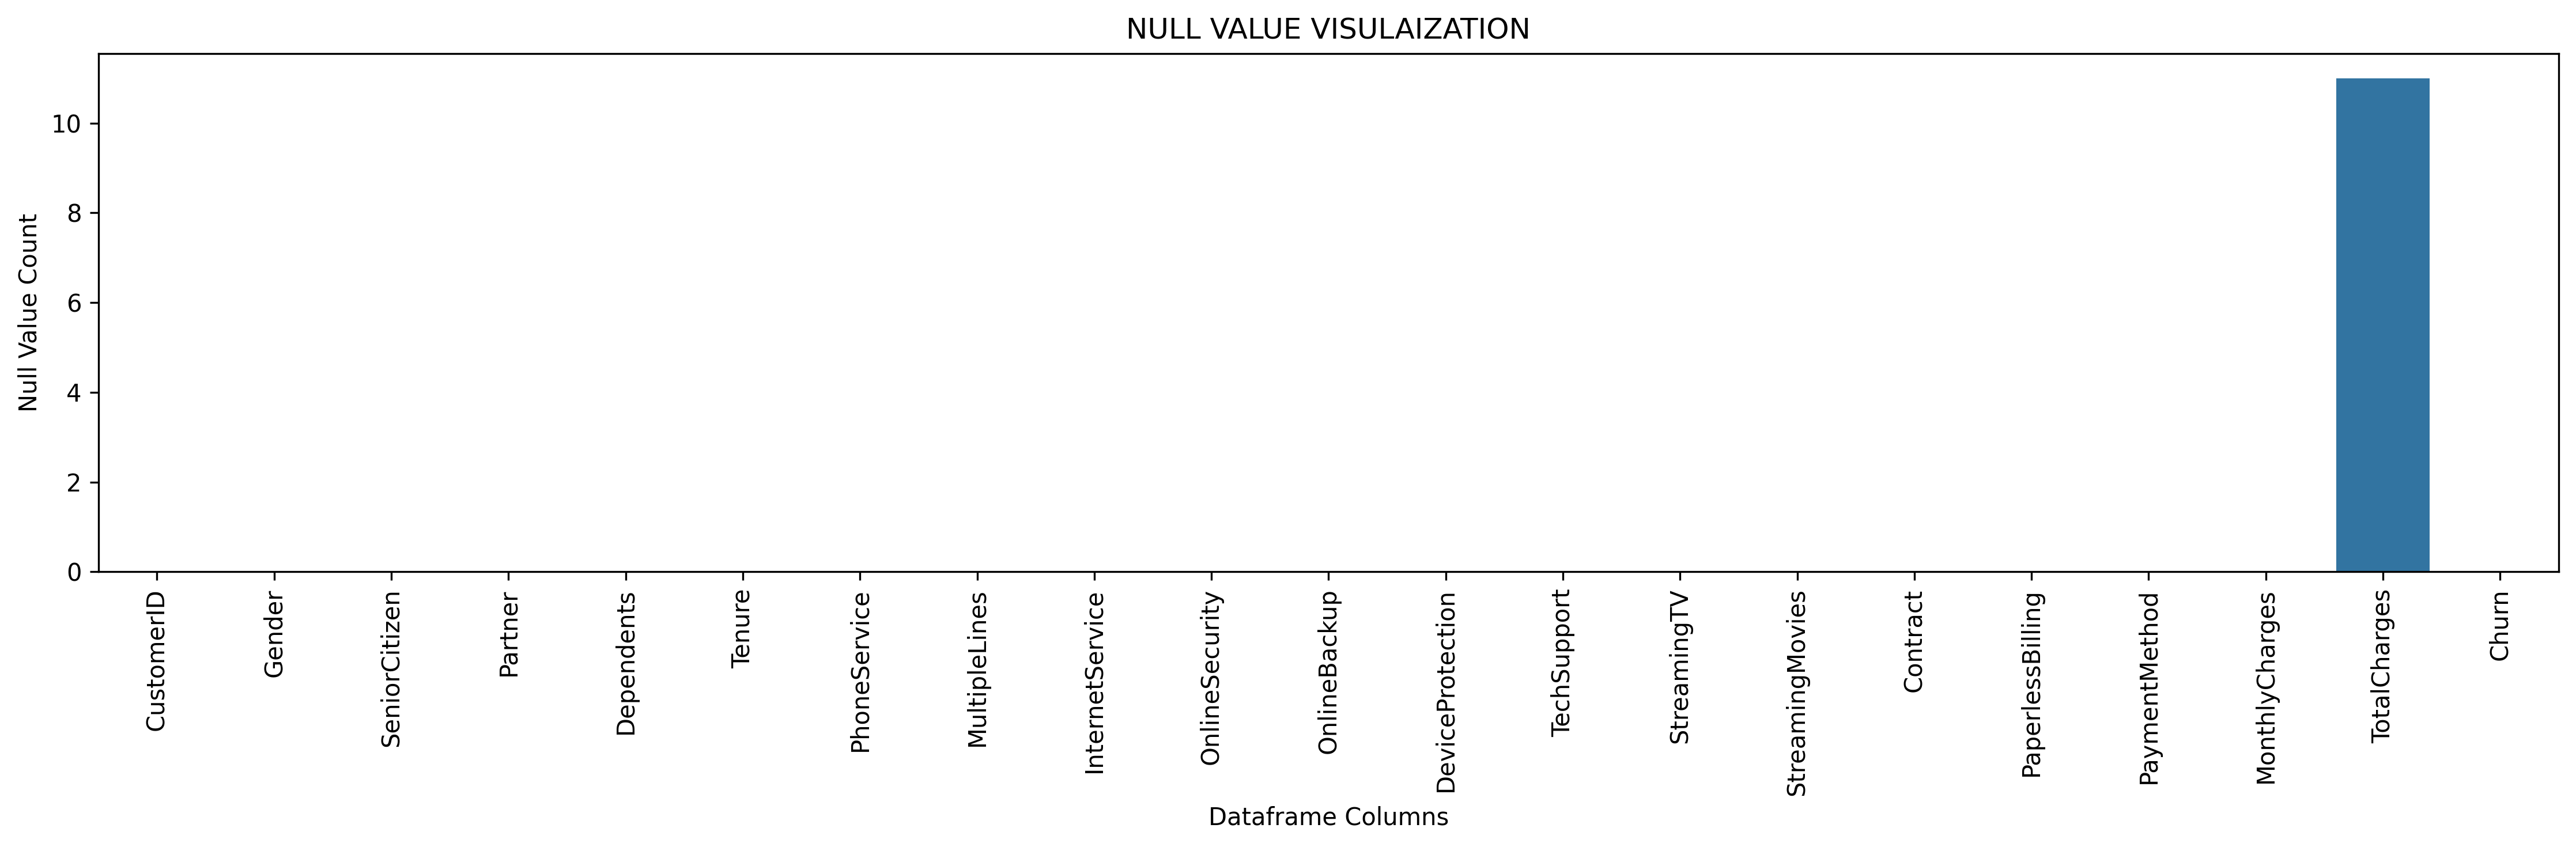

In [10]:
sns.barplot(x=(df == " ").sum().index,
           y=(df == " ").sum().values)
plt.xticks(rotation=90)
plt.xlabel("Dataframe Columns")
plt.ylabel("Null Value Count")
plt.title("NULL VALUE VISULAIZATION")
plt.tight_layout()
figure_file_path = FIGURE_DIR / "01_Null_Value_Visualization.png"
plt.savefig(figure_file_path)
plt.show()

**Interpretation:** There are total 11 (0.16%) missing values present in the `TotalCharges` column.

In [11]:
# Observing the rows with missing values:
df[df["TotalCharges"]==" "]

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


**Observation**: 
1. If we focus on the `Tenure` feature for these 11 records, we will observe that all of the 11 customers have Tenure = 0 which signifies that they haven't been with the company even for 1 month, so naturally there bill haven't been generated yet. As we know, **TotalCharges ≈ Tenure × MonthlyCharges**, so till date their TotalCharges should be also 0.
2. We can also conclude that, the TotalCharges feature is stored as string insted of numerical feature because of the presence of these emplty strings.

In [12]:
# Imputing the TotalCharges feature for all these 11 rows with 0 value.
df.loc[df["TotalCharges"]==" ","TotalCharges"] = '0'

# Converting the TotalCharges feature to numeric type.
df["TotalCharges"] = df["TotalCharges"].astype(float)

# Checking the datatypes again.
print(df.dtypes)

CustomerID              str
Gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
Tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


### Duplicate rows Inspection

In [13]:
df["CustomerID"].duplicated().value_counts()

CustomerID
False    7043
Name: count, dtype: int64

In [14]:
df[df.duplicated(keep=False)]

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


**Interpretation:** No duplicated rows or `customerID` is present.

## Part - B: Target Variable

### Overall target class distrbution

In [15]:
classes = df["Churn"].value_counts().index
class_count = df["Churn"].value_counts().values
class_pct = df["Churn"].value_counts(normalize=True).values
target_dict = {"TargetClass": [],
              "ClassCount": [],
              "DistributionPercentage": []}

for index,class_cat in enumerate(classes):
    target_dict["TargetClass"].append(class_cat)
    target_dict["ClassCount"].append(class_count[index])
    target_dict["DistributionPercentage"].append(round(class_pct[index]*100,2))

target_dist_df = pd.DataFrame.from_dict(target_dict)
target_dist_df

,TargetClass,ClassCount,DistributionPercentage
0,No,5174,73.46
1,Yes,1869,26.54


### Overall Churn Distribution Plot

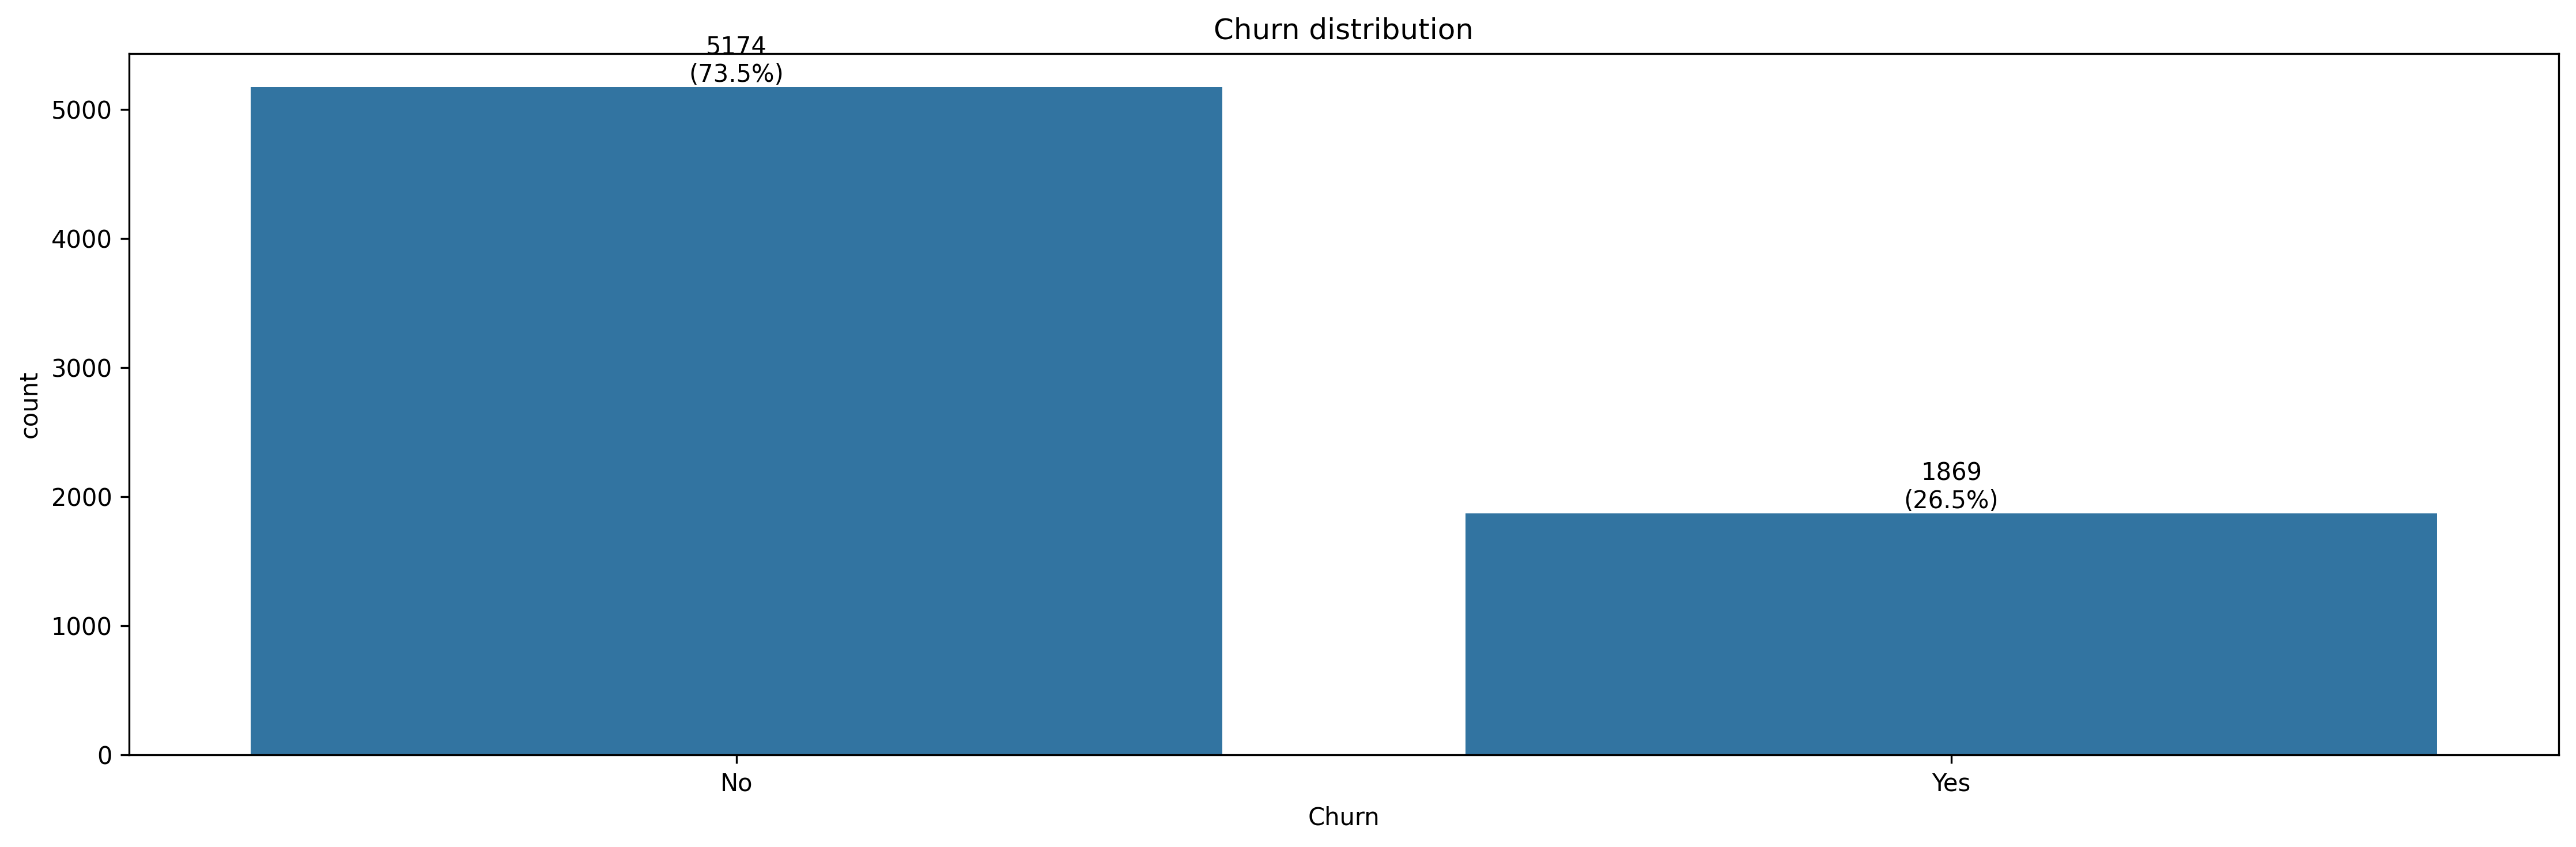

In [16]:
ax = sns.countplot(x="Churn", data=df, order=["No", "Yes"])
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f"{count}\n({pct:.1f}%)",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title("Churn distribution")
plt.tight_layout()
figure_file_path = FIGURE_DIR / "02_Target_Class_Distribution.png"
plt.savefig(figure_file_path, bbox_inches='tight')
plt.show()

**Interpretation:** 
1. The target feature contains only 2 classes i.e. Binary Class Classification.

2. The target class is imbalanced with **one class (didn't churn) accounting for almost 3/4th of data (~74%)** and the **other class (churned) covers only 1/4th data (~26%)**.

3. As, we know **accuracy = (correct predictions) / (total predictions)**. So, if the model predicts 85 correct predictions out of 100 total predictions then according to accuracy formula the model accuracy will be 85%.
    - But for this dataset as the majority class i.e. **didn't churn** is accounting for ~75% of the dataset, there is a high probability that the model trained on this dataset is likely to get biased towards this particular class.
    - The main aim of the model will be to tell *how many customers are likely to churn in future so the company can intervene* (offer discounts, call them, upgrade them to a longer contract).
    - So, even though model accuracy is high, this type of accuracy metric will lead to terrible business decisions.

4. This observation is highly significant for churn modelling because **minority class is the one you care about.** Customers who leave are rare, but they're the ones costing the company money. A model that's "97% accurate" but misses every actual churner is worse than useless — it's actively misleading, because the high number tricks managers into thinking the model is working.

5. The right metrics for this kind of problem are ones that explicitly look at how well model catch the minority class:

    i) **Precision** (for class = Yes): Of the customers the model flagged as likely-to-churn, what fraction actually churned? (Avoids false alarms.)

    ii) **Recall (Sensitivity / TPR)** (for class = Yes): Of the customers who actually churned, what fraction did the model catch? (Avoids missed churners.)

    iii) **F1-score**: Harmonic mean of the two — a balance.

    iv) **ROC-AUC**: Threshold-independent measure of how well the model separates the two classes.

    v) **PR-AUC** (precision-recall AUC): Especially good for imbalanced data; ROC-AUC can be optimistic when classes are skewed.

6. Given this asymmetry, **recall (TP / (TP + FN))** is the *primary metric* — it directly measures how many real churners we catch. However, recall in isolation can be gamed by predicting "Yes" for everyone, so I'll also track **precision** as a *secondary metric* to ensure the retention team isn't flooded with false alarms, and **F1** as a *balance metric*. I'll also report **PR-AUC** because it's a threshold-independent metric well-suited to imbalanced classification. 

7. In production, the decision threshold can be tuned based on the retention team's actual budget.

## Part C — Numerical Features: `Tenure`, `MonthlyCharges`, `TotalCharges`

### Summary statistics of numerical columns

In [17]:
df[["Tenure","MonthlyCharges","TotalCharges"]].describe()

,Tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


### Distribution Plot of Numerical Features

Median: 29.0
Mean: 32.4


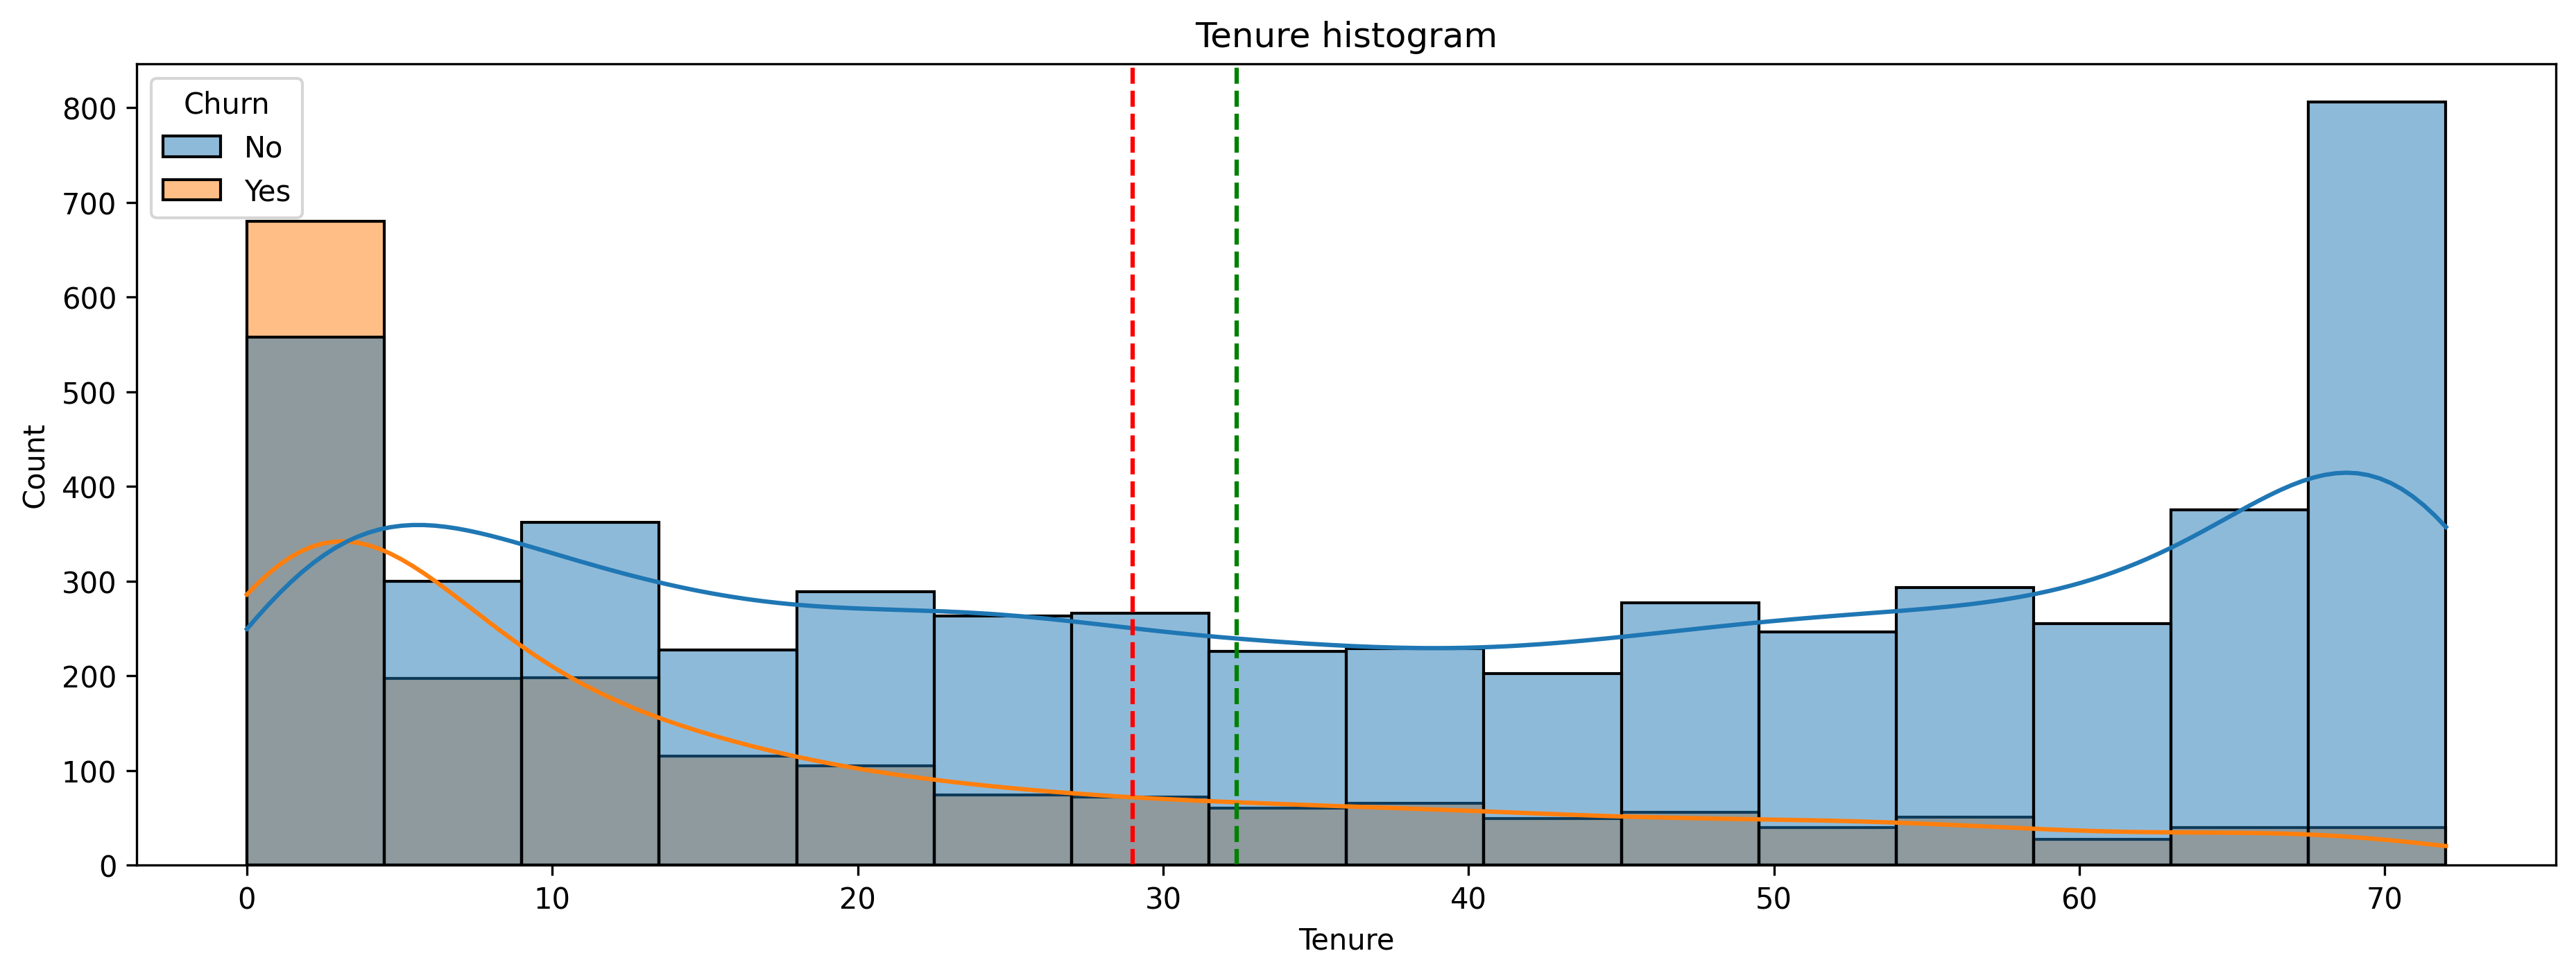

In [18]:
# Checking the distribution of the numerical features—Tenure:
utils.histogrammer(df=df, 
                   column="Tenure",
                   save_fig=True,
                   kde=True,
                   fill=True,
                   data=df,
                   hue="Churn",)

**Interpretation**: `Tenure` is *bimodal* with strong peaks at 0–2 months and 69–72 months. This reveals two distinct customer populations: *high-churn-risk newcomers* and *self-selected long-term loyalists*—with a sparse middle.  The non-linear relationship between tenure and churn risk (tenure↑ → churn risk↓) means I'll engineer a `tenure_bucket` categorical feature to capture this non-linearity.

Skewness: -0.2
Kurtosis: 1.7


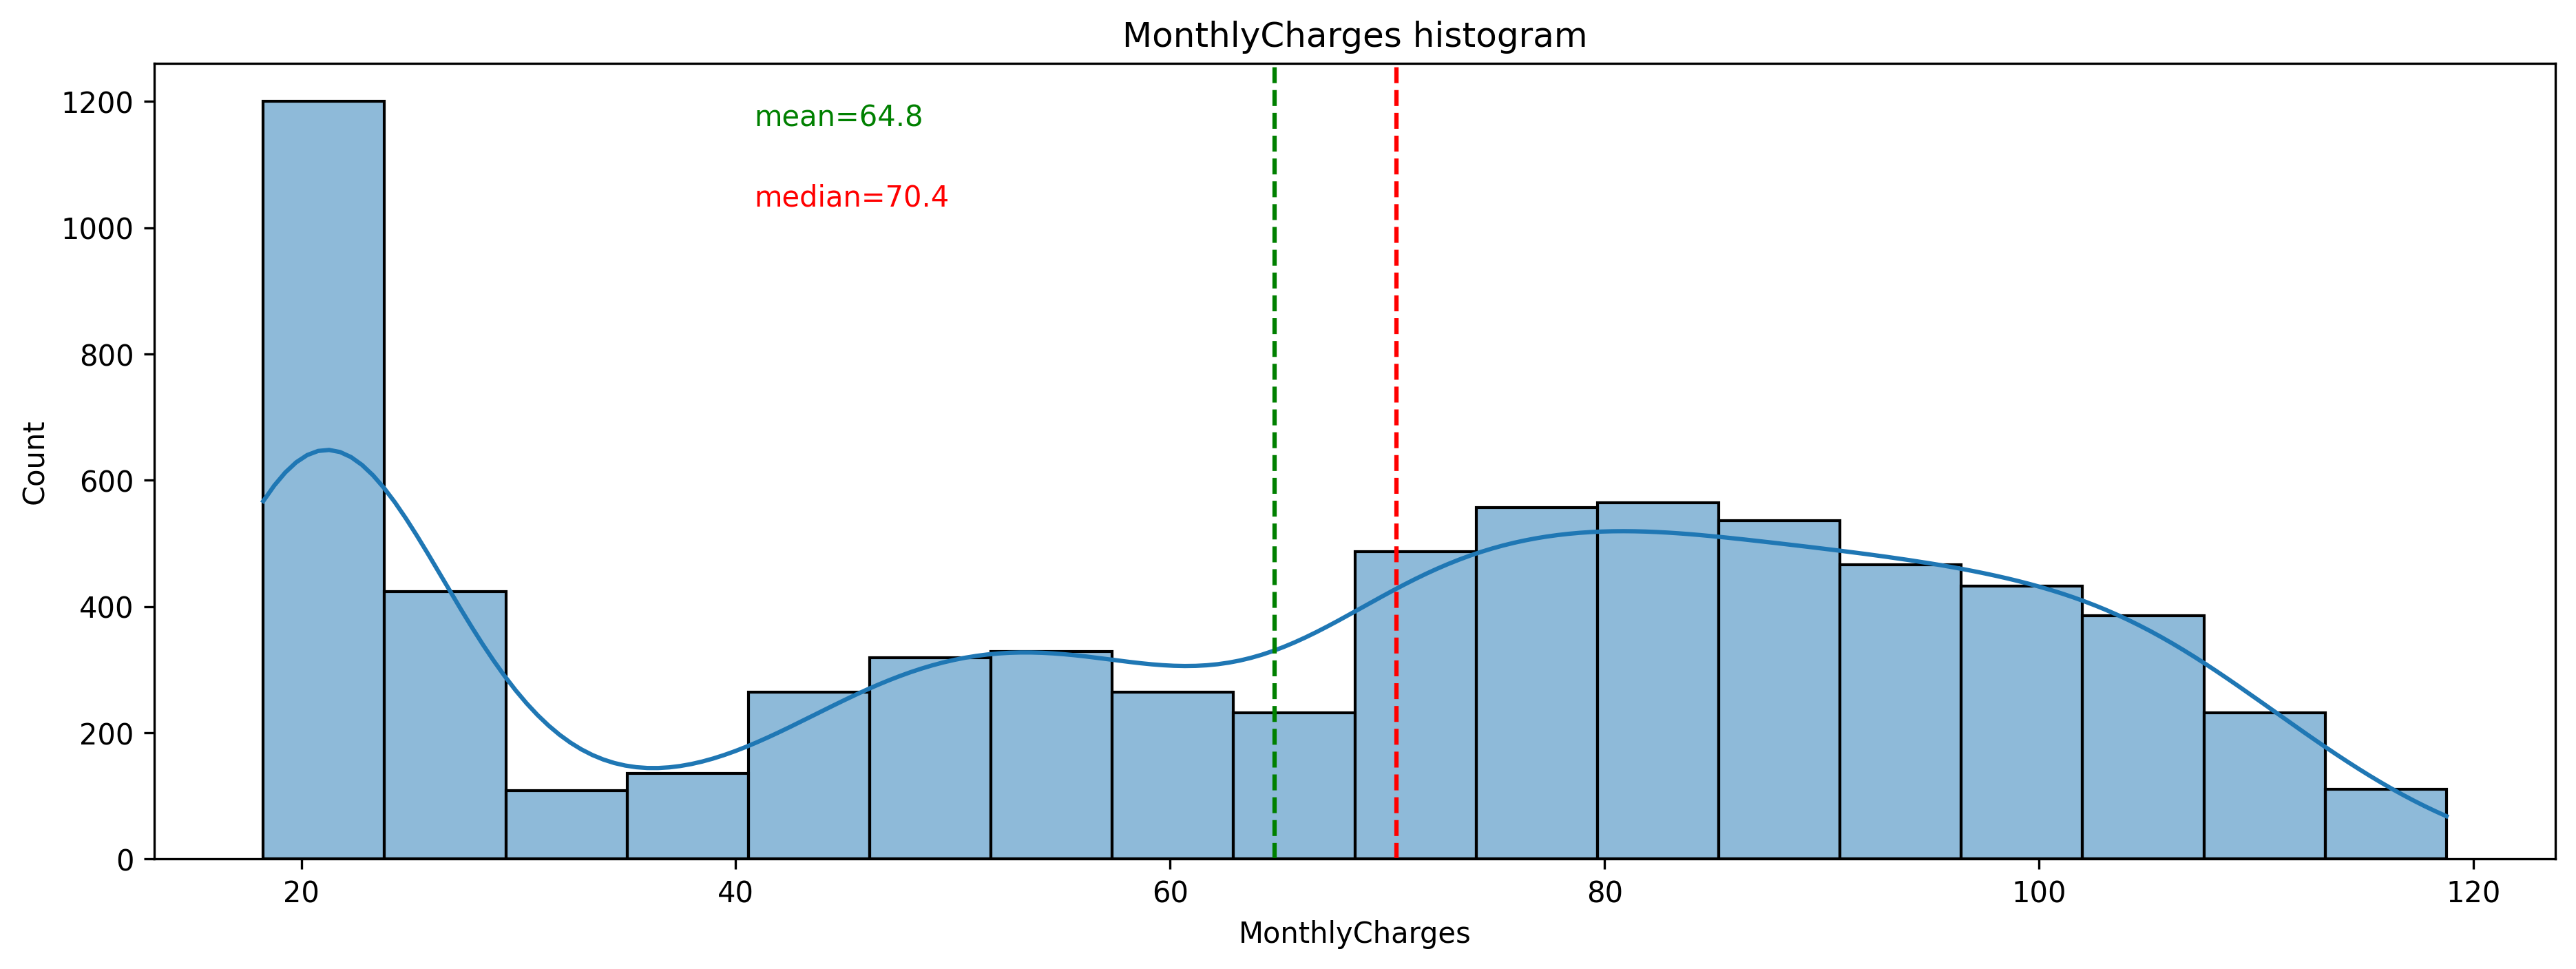

In [19]:
# Checking the distribution of the numerical features—MonthlyCharges:
utils.histogrammer(df=df, 
                   column="MonthlyCharges",
                   save_fig=True,
                   kde=True,
                   fill=True,
                   )

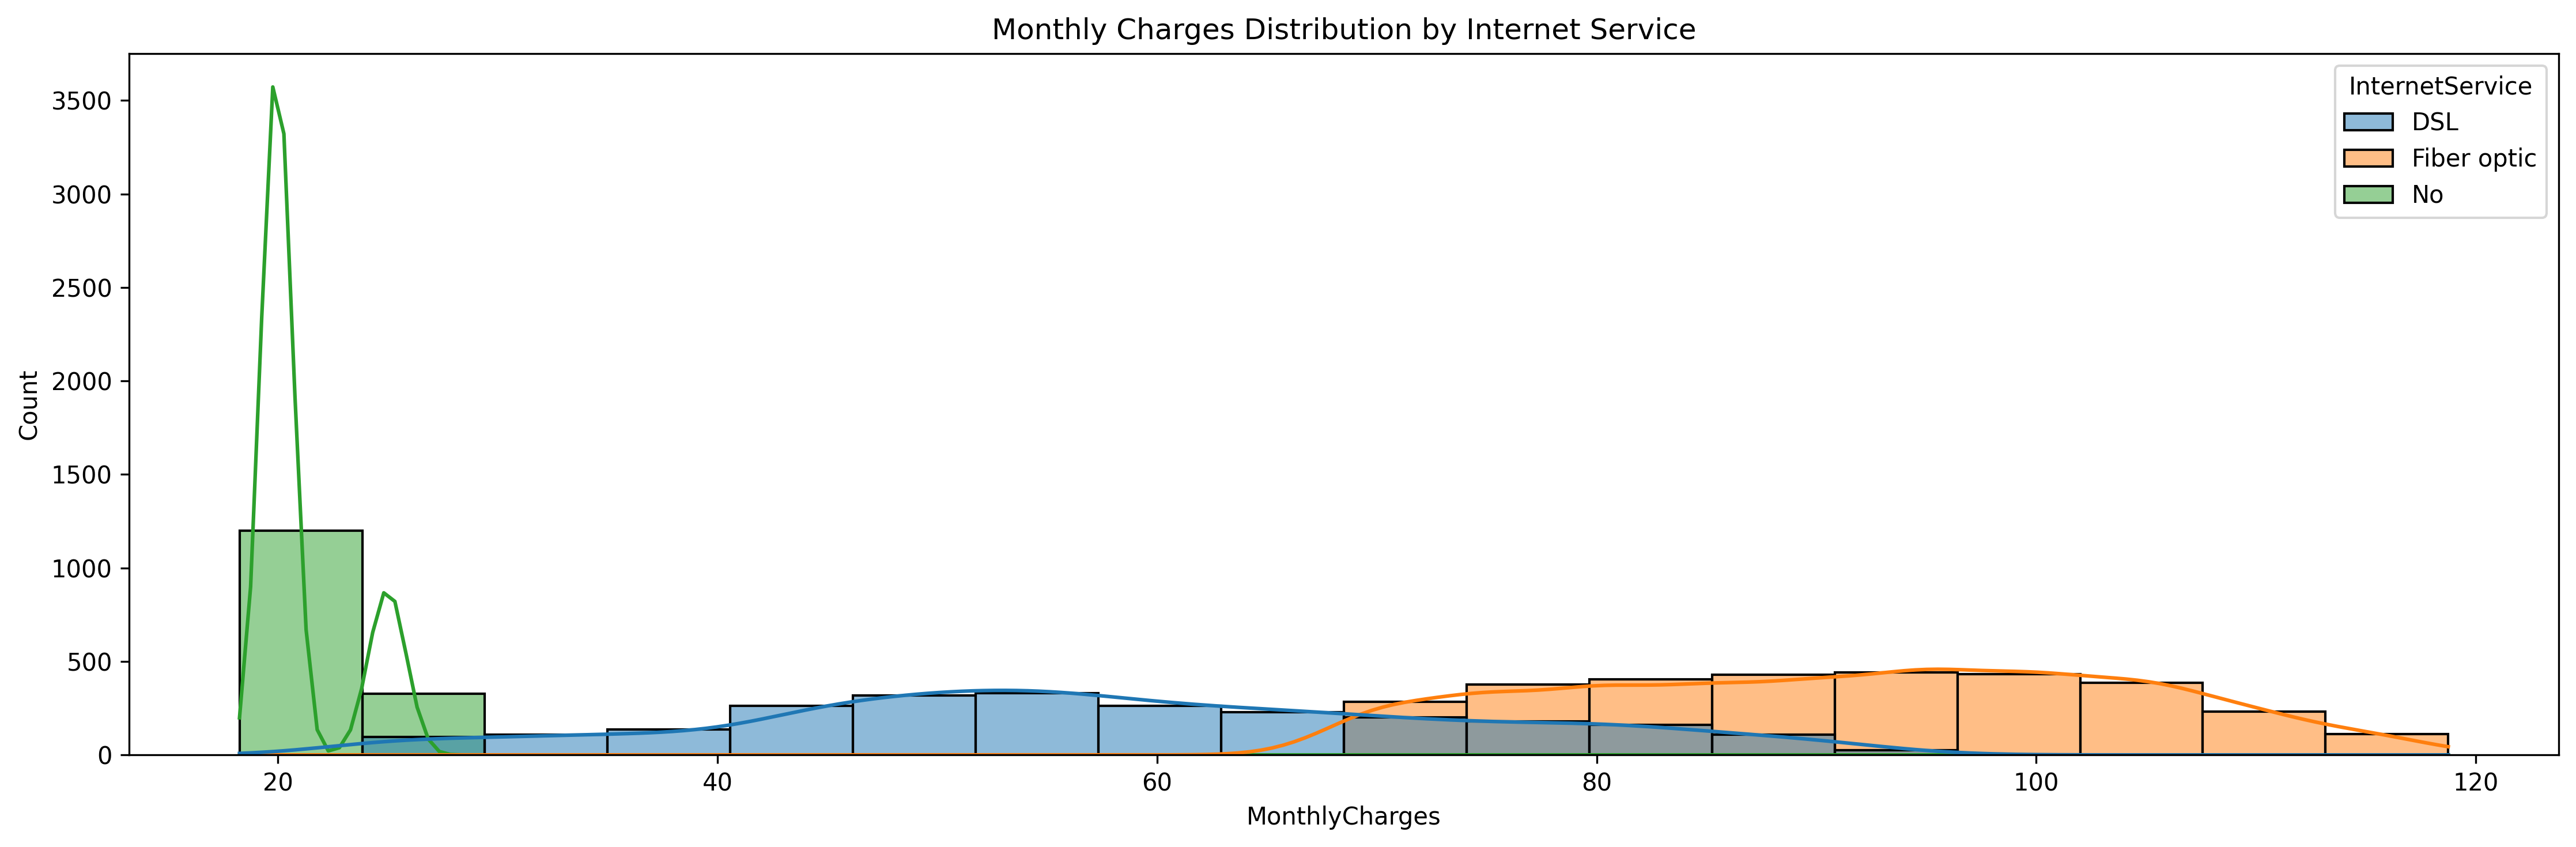

In [20]:
sns.histplot(x="MonthlyCharges", data=df, kde=True, fill=True, hue="InternetService")
plt.title("Monthly Charges Distribution by Internet Service")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "MonthlyCharges_Distribution_by_InternetService.png", bbox_inches='tight')
plt.show()

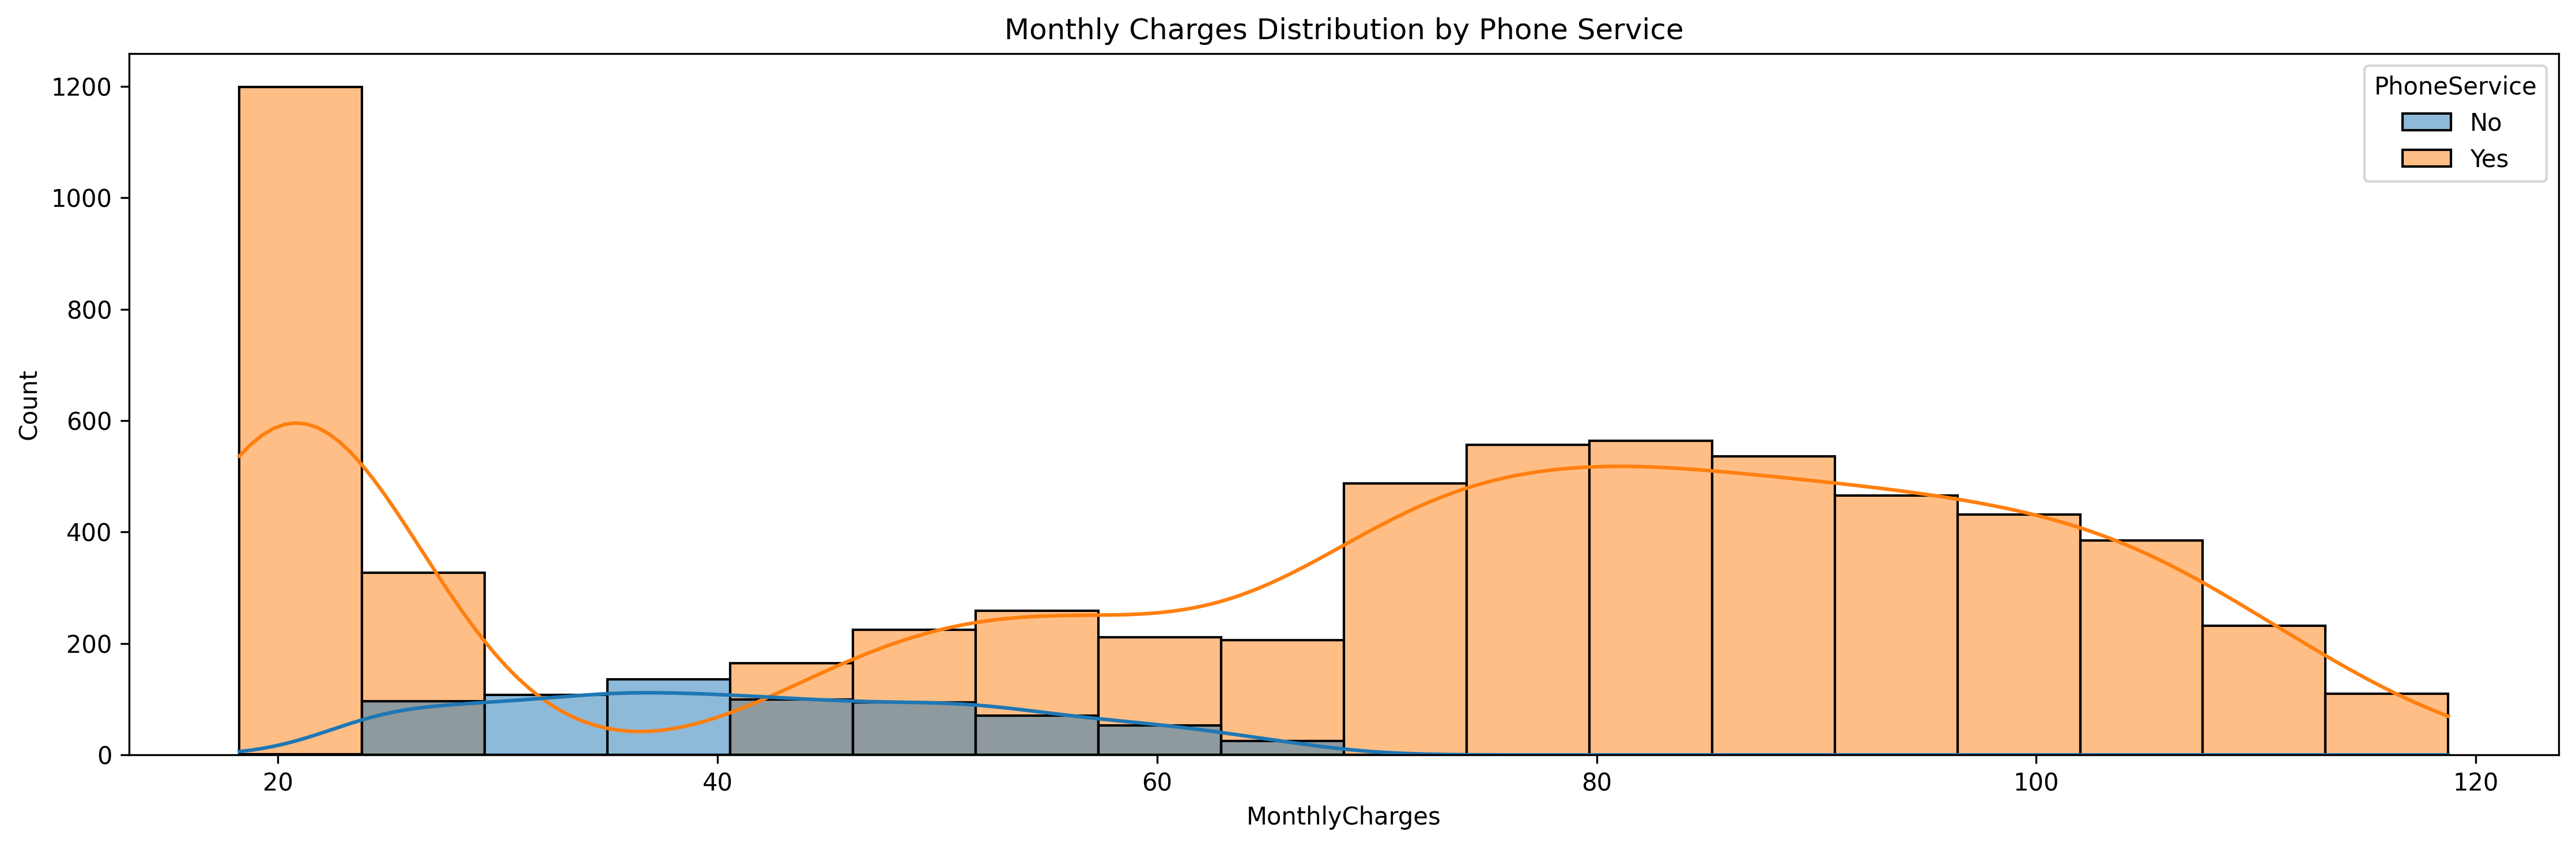

In [21]:
sns.histplot(x="MonthlyCharges", data=df, kde=True, fill=True, hue="PhoneService")
plt.title("Monthly Charges Distribution by Phone Service")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "MonthlyCharges_Distribution_by_PhoneService.png", bbox_inches='tight')
plt.show()

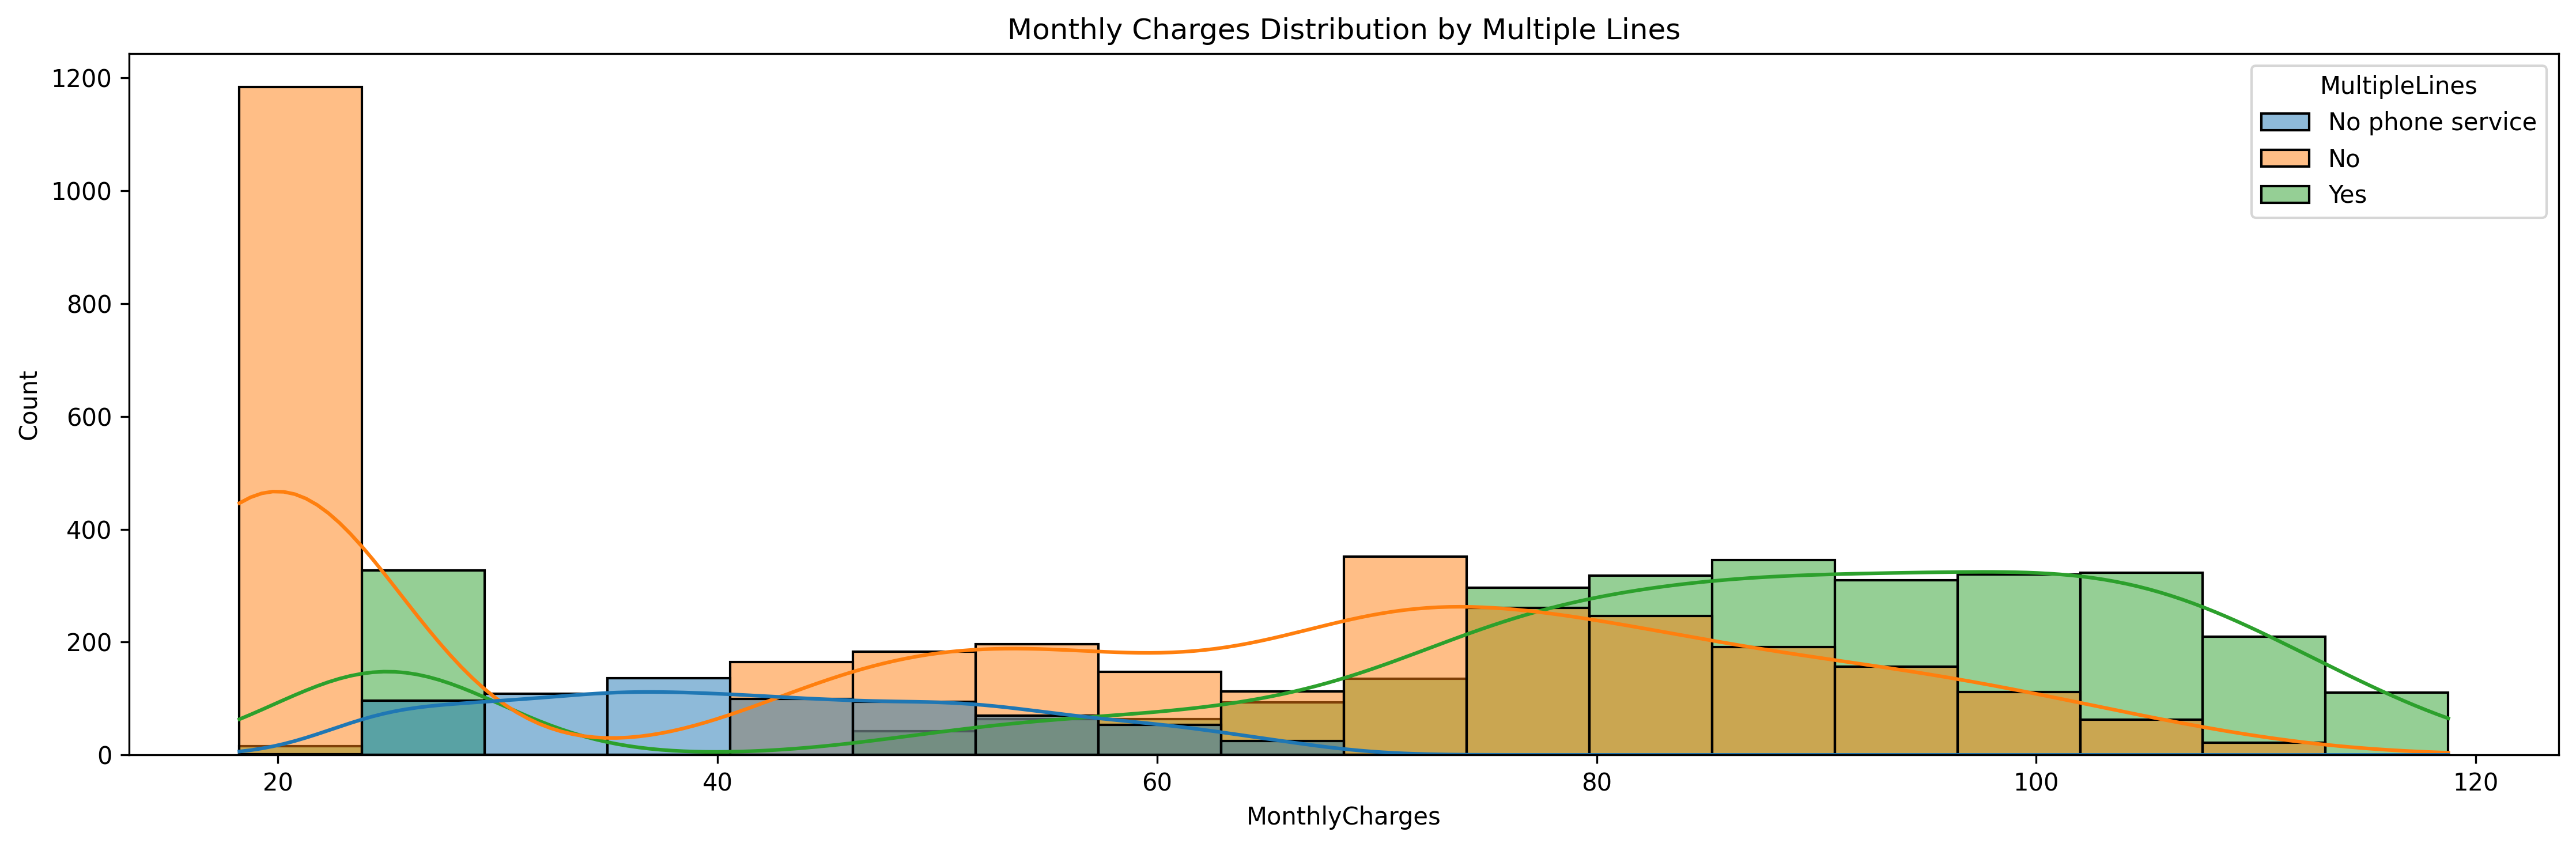

In [22]:
sns.histplot(x="MonthlyCharges", data=df, kde=True, fill=True, hue="MultipleLines")
plt.title("Monthly Charges Distribution by Multiple Lines")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "MonthlyCharges_Distribution_by_MultipleLines.png", bbox_inches='tight')
plt.show()

In [23]:
display(df.groupby('InternetService')['MonthlyCharges'].agg(["mean"]))
display(df.groupby('PhoneService')['MonthlyCharges'].agg(["mean"]))
display(df.groupby('MultipleLines')['MonthlyCharges'].agg(["mean"]))

,mean
InternetService,
DSL,58.102169
Fiber optic,91.500129
No,21.079194


,mean
PhoneService,
No,42.028592
Yes,67.199041


,mean
MultipleLines,
No,54.195059
No phone service,42.028592
Yes,82.036974


In [24]:
display(df.groupby(['InternetService', 'PhoneService', 'MultipleLines'])['MonthlyCharges'].agg(["mean"]))

mean
InternetService PhoneService MultipleLines              
DSL             No           No phone service  42.028592
                Yes          No                59.303483
                             Yes               72.144428
Fiber optic     Yes          No                84.580570
                             Yes               95.634727
No              Yes          No                19.955152
                             Yes               24.970614

**Interpretation**: `MonthlyCharges` is *trimodal* with peaks at roughly **$20**, **$55**, and **$90**. These correspond to *three structural pricing tiers*: ***phone-only customers***, ***DSL internet customers***, and ***fiber optic customers*** confirmed by groupby on `InternetService`. The multimodality is structural — driven by the discrete pricing of service bundles(InternetService, PhoneService, MultipleLines), captured by the `InternetService` feature.

Median: 1394.6
Mean: 2279.7


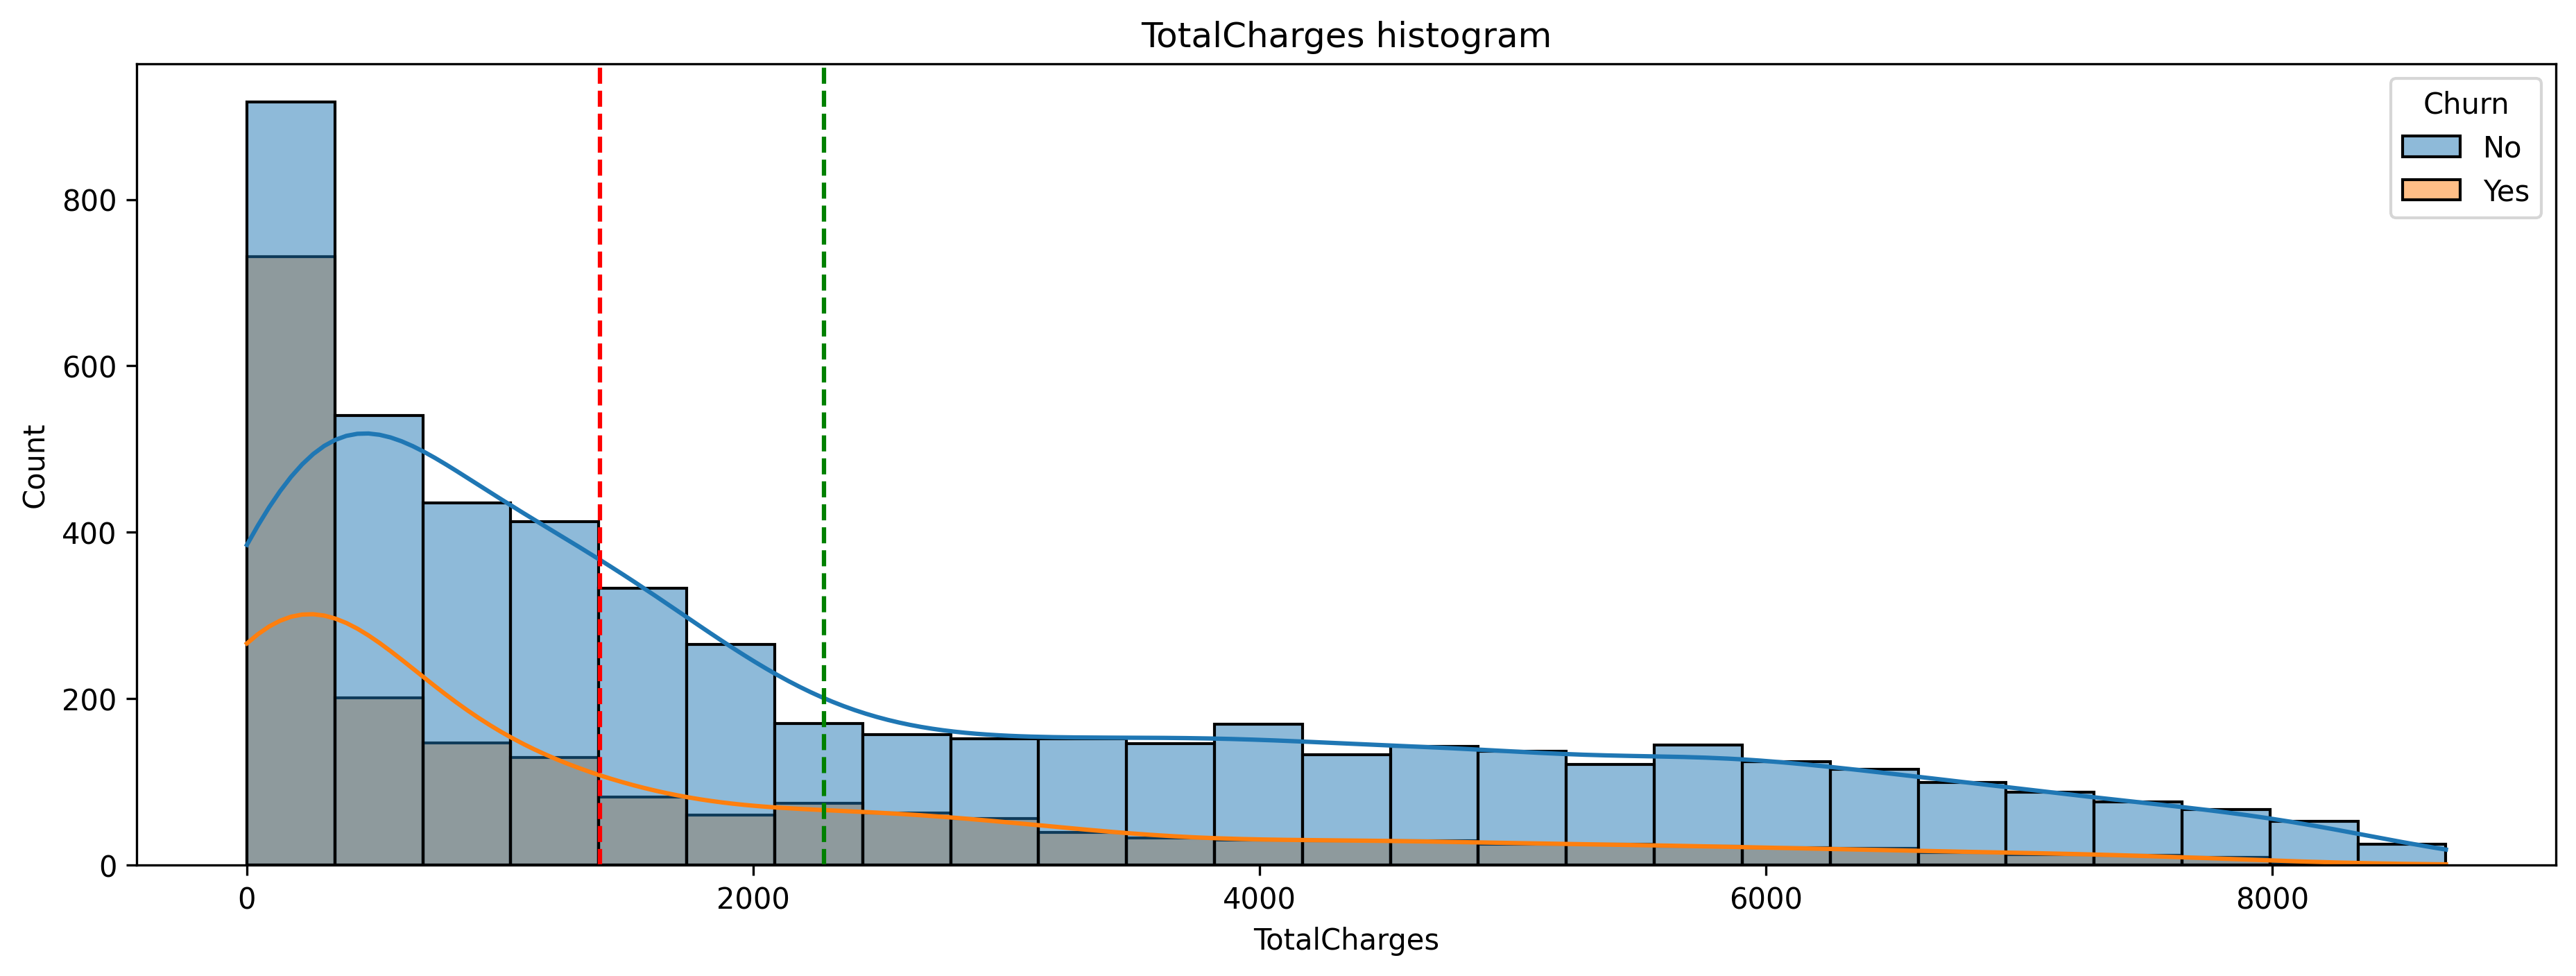

In [25]:
# Checking the distribution of the numerical features—TotalCharges:
utils.histogrammer(df=df, 
                   column="TotalCharges",
                   save_fig=True,
                   kde=True,
                   fill=True,
                   data=df,
                   hue="Churn",)

**Interpretation**: 
1. `TotalCharges` is *right-skewed* (skewness ≈ [your number]) with a long tail. This is expected because `TotalCharges` is approximately **Tenure × MonthlyCharges**, both bounded below by zero with no upper limit, so it inherits the lower bound at zero and the variance of both inputs.
2. Mean is misleading because it is pulled up by the tail; median is the more honest central tendency. 
3. For linear models (e.g. Linear Regression, Logistic Regression), a **log transform**(np.log1p(df['TotalCharges'])) is recommended because it would normalize this distribution; for tree models (e.g. Decision Tree, Random Forest), no transformation is needed. 
4. The relationship with tenure also raises a multicollinearity concern which we will deal with further analysis.

### Outlier Detection for the 3 Numerical features: Tenure, MonthlyCharges, TotalCharges

In [26]:
num_feature = ["Tenure","MonthlyCharges","TotalCharges"]
utils.detect_outliers(df=df, columns=num_feature)

Tenure               | IQR=[9.00, 55.00] | bounds=[-60.00, 124.00] | low=0 | high=0
MonthlyCharges       | IQR=[35.50, 89.85] | bounds=[-46.02, 171.38] | low=0 | high=0
TotalCharges         | IQR=[398.55, 3786.60] | bounds=[-4683.52, 8868.67] | low=0 | high=0


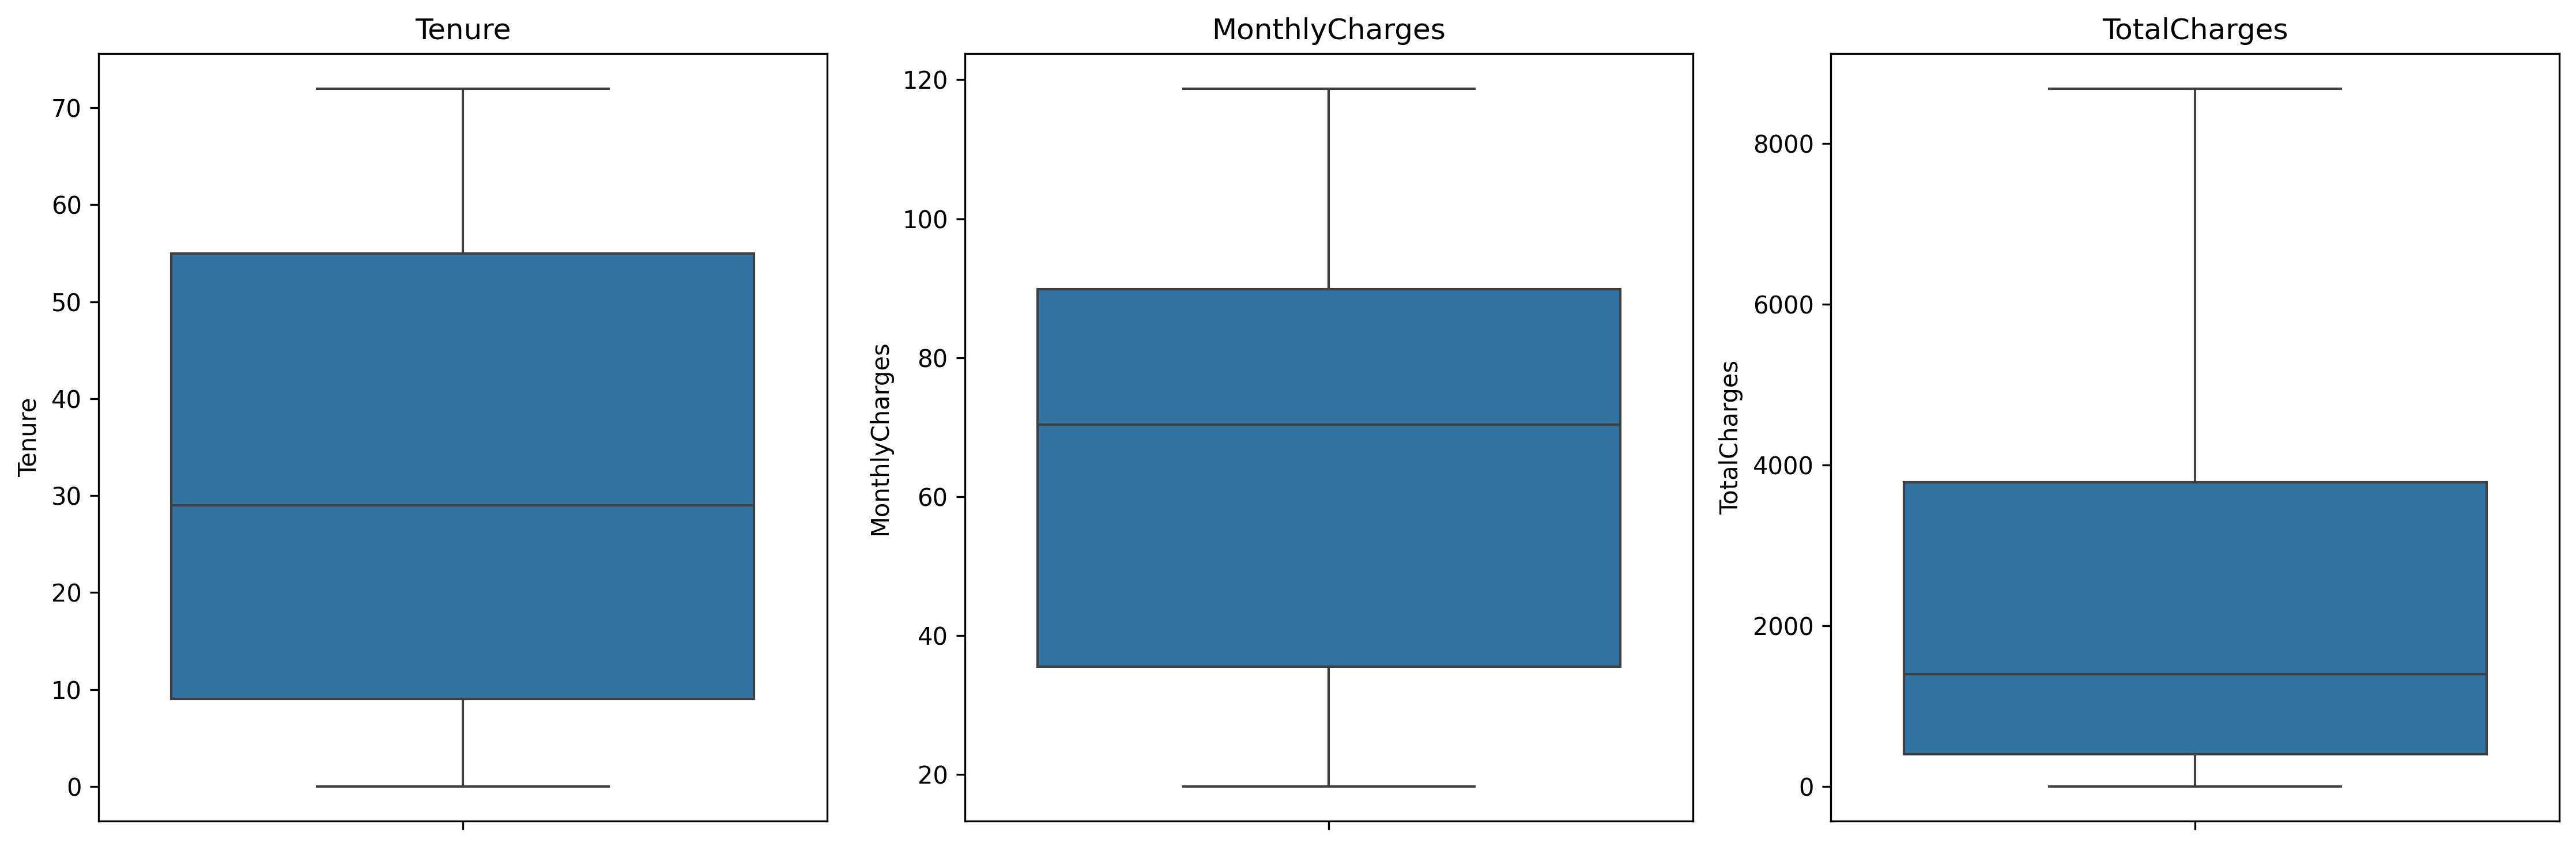

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, column in enumerate(num_feature):
    sns.boxplot(y=df[column], ax=axes[i])
    axes[i].set_title(column)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "Boxplots_Numerical_Features.png", bbox_inches='tight')
plt.show()

**Outlier analysis**: By the standard ***1.5×IQR rule***, none of the three numerical features contain outliers. However, this is partly an artifact of the data being bounded by design (tenure caps at 72 months, MonthlyCharges caps around $120 due to pricing tiers). *The absence of IQR outliers does not mean the distributions are well-behaved for modeling*:

- TotalCharges is heavily right-skewed and may still benefit from a log transform before linear modeling, even though no points are flagged as outliers.
- The **11 rows with `tenure=0`** identified previously are arguably outliers from a business perspective (brand-new customers with no billing history) even though they pass the IQR test.

### box plots of each numeric feature `split by churn`

In [28]:
# Checking for outliers in the Tenure, MonthlyCharges, TotalCharges features for the with respect to Churned feature:
print("="*20+"For retained customers"+"="*20)
utils.detect_outliers(df=df[df['Churn'] == 'No'], columns=num_feature)
print("\n")
print("="*20+"For churned customers"+"="*20)
utils.detect_outliers(df=df[df['Churn'] == 'Yes'], columns=num_feature)

====================For retained customers====================
Tenure               | IQR=[15.00, 61.00] | bounds=[-54.00, 130.00] | low=0 | high=0
MonthlyCharges       | IQR=[25.10, 88.40] | bounds=[-69.85, 183.35] | low=0 | high=0
TotalCharges         | IQR=[572.90, 4262.85] | bounds=[-4962.02, 9797.77] | low=0 | high=0


====================For churned customers====================
Tenure               | IQR=[2.00, 29.00] | bounds=[-38.50, 69.50] | low=0 | high=23
MonthlyCharges       | IQR=[56.15, 94.20] | bounds=[-0.93, 151.28] | low=0 | high=0
TotalCharges         | IQR=[134.50, 2331.30] | bounds=[-3160.70, 5626.50] | low=0 | high=109


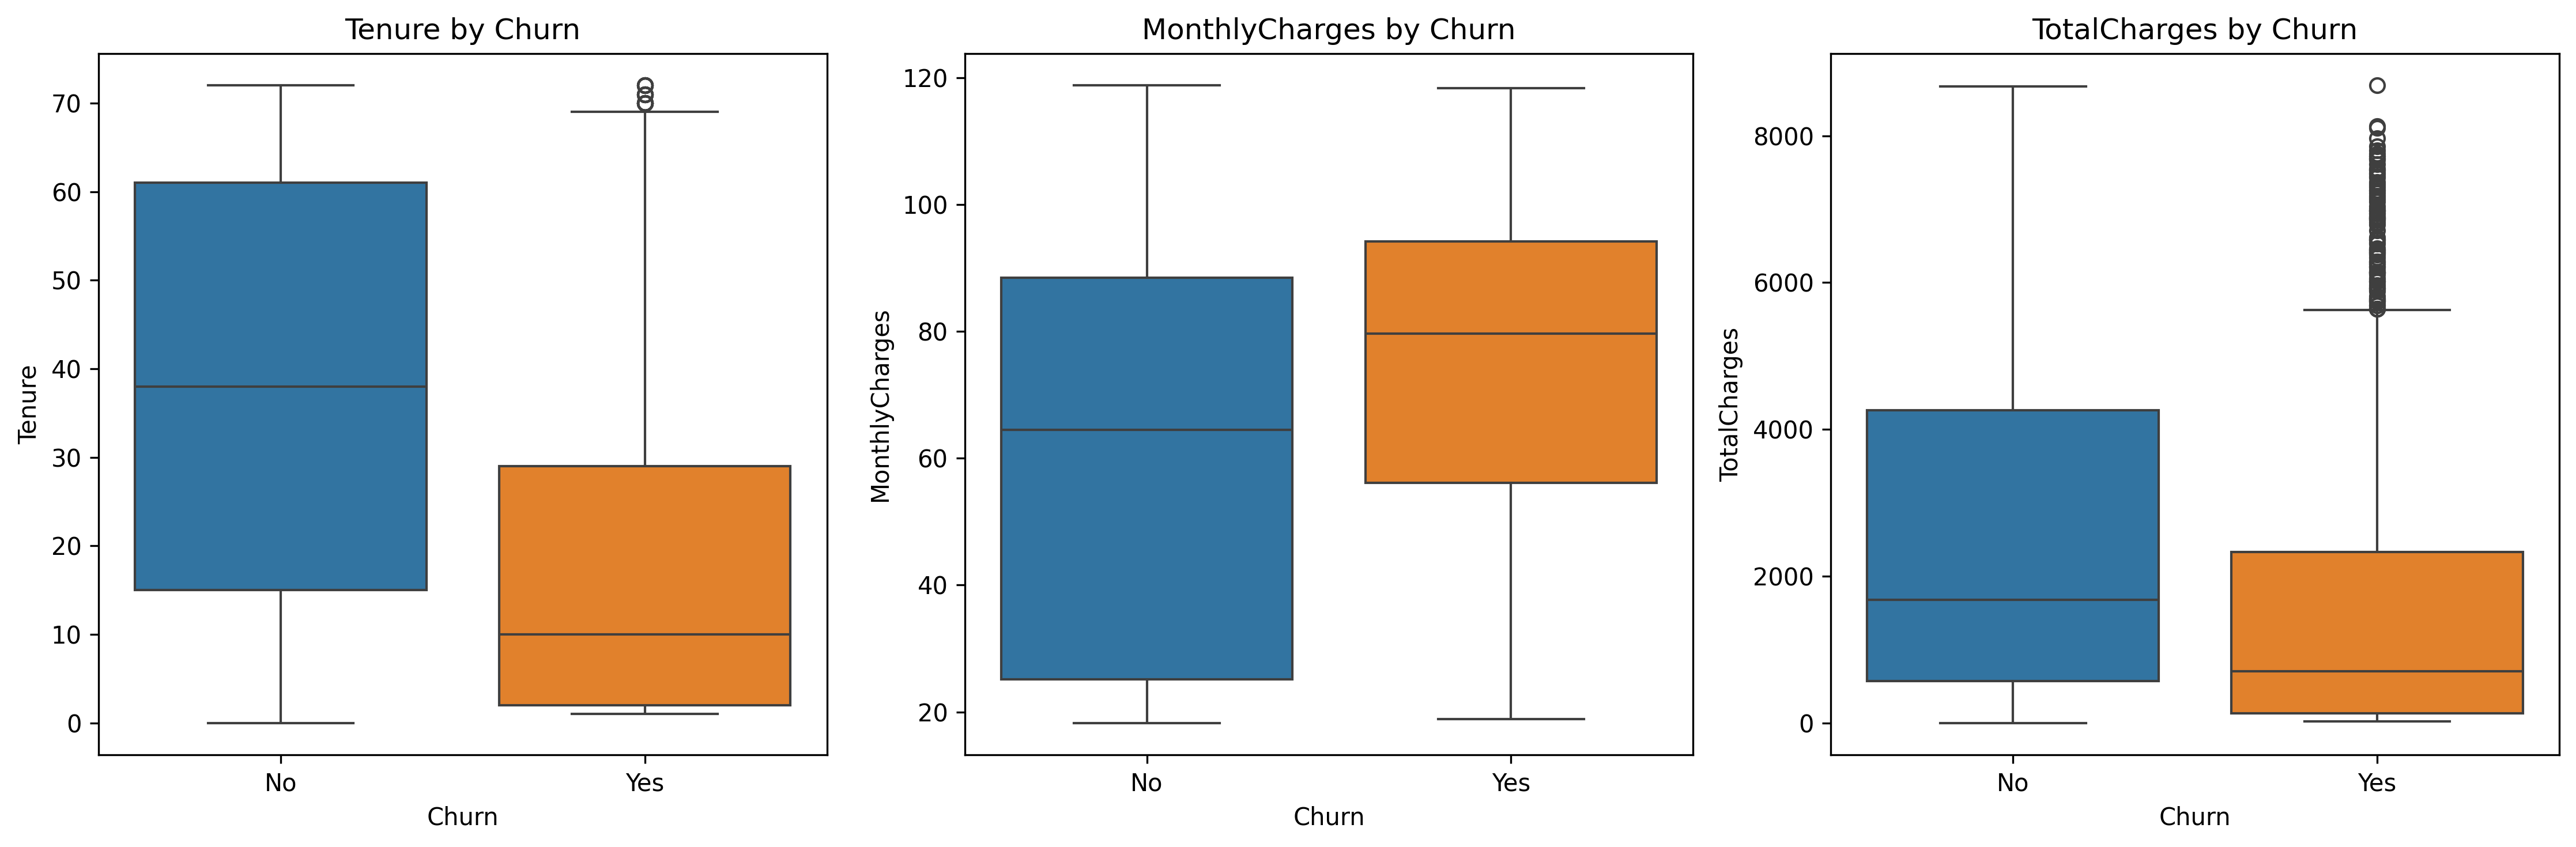

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, num_feature):
    sns.boxplot(data=df, x='Churn', y=col, ax=ax, order=['No', 'Yes'], hue="Churn")
    ax.set_title(f'{col} by Churn')

plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_numerical_features_by_churn.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
df.groupby('Churn')[['Tenure', 'MonthlyCharges', 'TotalCharges']].agg(['median', 'mean', 'std'])

Tenure                       MonthlyCharges                        \
      median       mean        std         median       mean        std   
Churn                                                                     
No      38.0  37.569965  24.113777         64.425  61.265124  31.092648   
Yes     10.0  17.979133  19.531123         79.650  74.441332  24.666053   

      TotalCharges                            
            median         mean          std  
Churn                                         
No        1679.525  2549.911442  2329.954215  
Yes        703.550  1531.796094  1890.822994

**Interpretation**:

1. `Tenure × Churn`: Median tenure of *churners* is **10 months vs 38 months** for *retained customers* — a **3.8× ratio** and the ***largest gap*** in the dataset. The IQRs (churner: ~2–29, retained: ~15–61) *barely overlap*. ***Tenure is almost certainly the single strongest predictor of churn***.

2. `MonthlyCharges × Churn`: Median MonthlyCharges of *churners* is **$79.65 vs $64.42** for *retained customers* (**1.24× ratio**). The IQRs (churner: ~56–94, retained: ~25–88) *overlap substantially* (~$56–88), meaning MonthlyCharges alone is a weaker predictor than tenure. The shift toward higher monthly bills among *churners* is consistent with the hypothesis that expensive customers — particularly fiber optic customers — are more churn-prone.

3. `TotalCharges × Churn`: Median TotalCharges of *churners* is **$703 vs $1,680** for *retained customers* (**2.4× ratio**). The IQRs (churner: ~134–2331, retained: ~572–4262) *overlap moderately*. This appears to be strong separation, but recall that TotalCharges ≈ tenure × MonthlyCharges — so most of this signal is derivative of the tenure signal. TotalCharges may show up as predictive in univariate analysis but is likely redundant once tenure is included in the model.

### Relationship between tenure vs TotalCharges: `TotalCharges ≈ Tenure × MonthlyCharges`

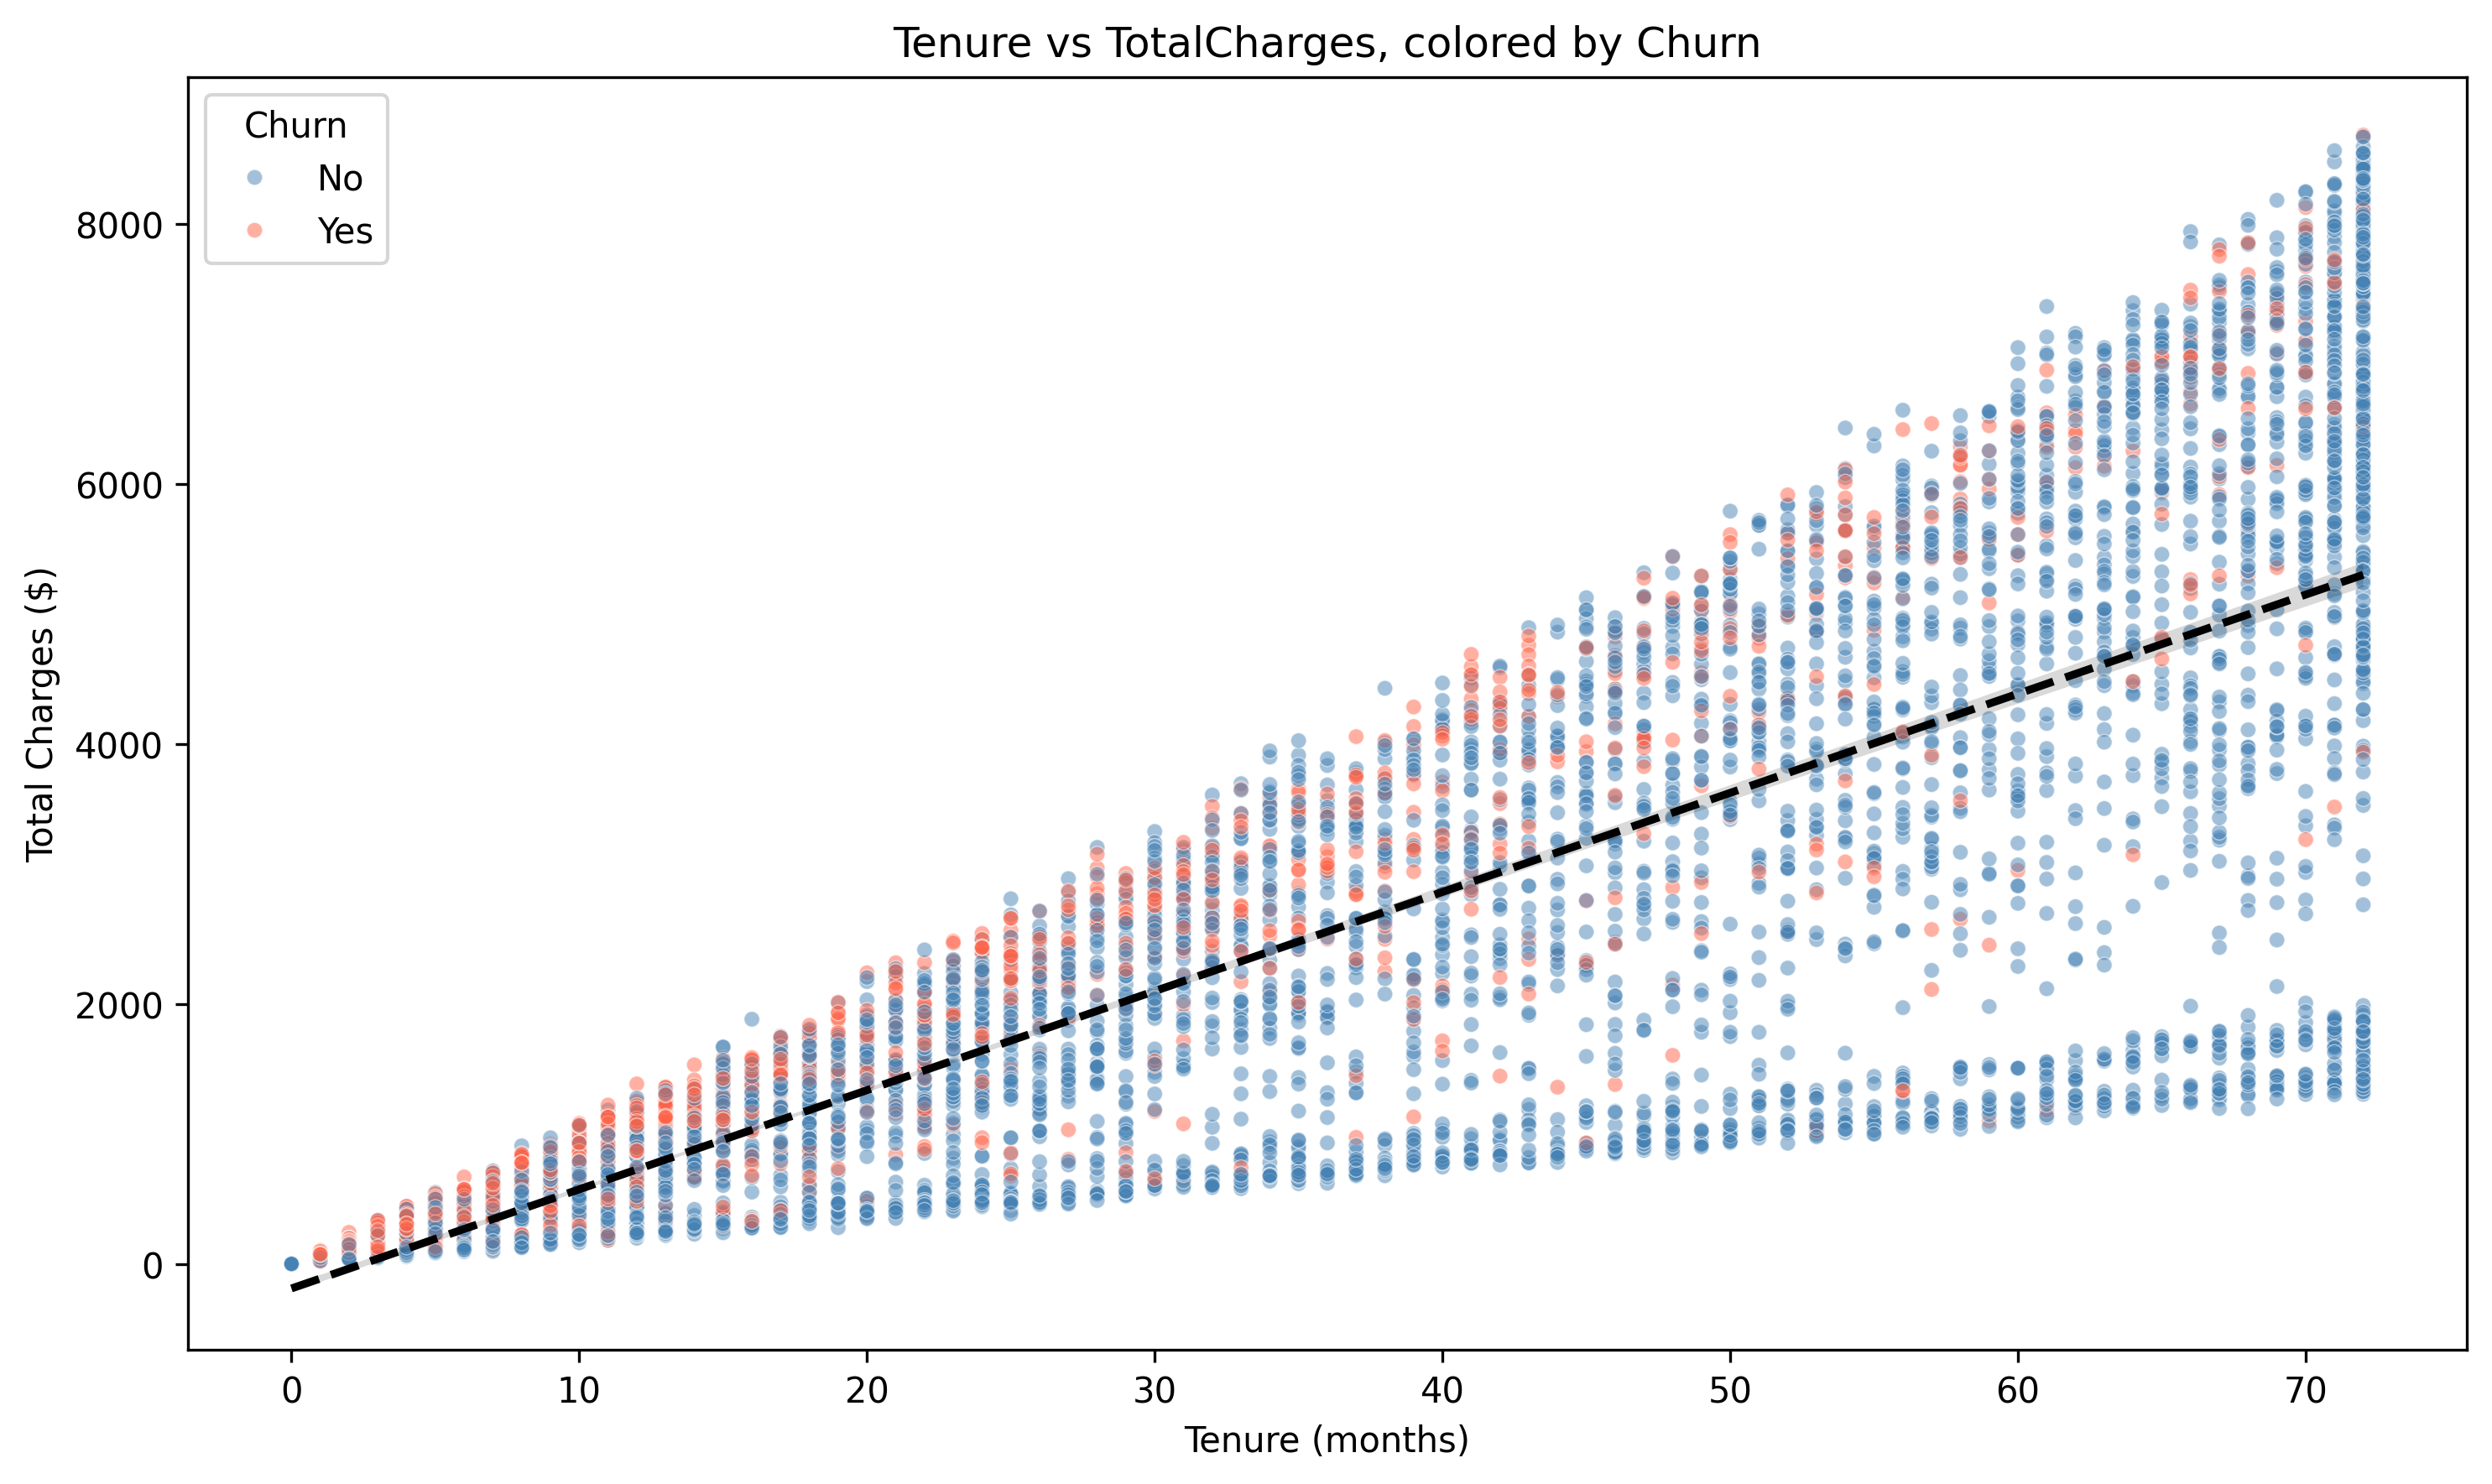

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Tenure', y='TotalCharges',
                hue='Churn', hue_order=['No', 'Yes'],
                palette={'No': 'steelblue', 'Yes': 'tomato'},
                alpha=0.5, s=20)
sns.regplot(data=df, x='Tenure', y='TotalCharges',
            scatter=False, color='black', line_kws={'linestyle': '--'})
plt.title('Tenure vs TotalCharges, colored by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Total Charges ($)')
plt.legend(title='Churn')
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_tenure_vs_totalcharges_by_churn.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
corr = df['Tenure'].corr(df['TotalCharges'])
print(f"Pearson correlation: {corr:.3f}")

Pearson correlation: 0.826


**Interpretation**: 
- *TotalCharges* is effectively a cumulative metric — it's the sum of every monthly bill the customer has paid since signing up. By construction, `TotalCharges ≈ tenure × MonthlyCharges`. So a strong positive correlation between *Tenure* and *TotalCharges* (~0.83) is mechanical, not a discovery. The relationship isn't learned from the data — it's a definitional property of how the telecom company bills its customers.
- The **fan-shape** (variance increasing with tenure) reflects that customers on different service tiers (~$20 phone-only to ~$110 fiber + add-ons) accumulate billing at very different rates. At 1 month, everyone has paid ~$20–$110. At 70 months, customers have paid anywhere from ~$1,400 to ~$7,700 — the same 6× variance, but multiplied out across time.
- The business-relevant insight in this plot isn't the trend itself — it's that churned customers (red) cluster in the lower-left, confirming that churn is overwhelmingly a phenomenon of new customers who haven't accumulated much billing history. This is consistent with the bimodal tenure finding in  Tenure distribution histogram plot and the box plot separation.
- Because TotalCharges is essentially derived from tenure (and MonthlyCharges), it carries little information beyond what those two features already provide. Expected to see strong multicollinearity in further analysis, and a feature-importance discussion.

## Part D — Categorical Features

### Categorical features inventory

In [33]:
categorical_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
categorical_cols.append('SeniorCitizen')
if 'CustomerID' in categorical_cols:
    categorical_cols.remove('CustomerID')

summary = pd.DataFrame({
    'feature': categorical_cols,
    'dtype': [df[c].dtype for c in categorical_cols],
    'n_unique': [df[c].nunique() for c in categorical_cols],
    'unique_values': [sorted(df[c].unique().tolist(), key=str) for c in categorical_cols],
})
summary = summary.sort_values('n_unique').reset_index(drop=True)
summary

,feature,dtype,n_unique,unique_values
0,Gender,str,2,"[Female, Male]"
1,Partner,str,2,"[No, Yes]"
2,Dependents,str,2,"[No, Yes]"
3,PhoneService,str,2,"[No, Yes]"
4,PaperlessBilling,str,2,"[No, Yes]"
5,Churn,str,2,"[No, Yes]"
6,SeniorCitizen,int64,2,"[0, 1]"
7,MultipleLines,str,3,"[No, No phone service, Yes]"
8,OnlineBackup,str,3,"[No, No internet service, Yes]"
9,OnlineSecurity,str,3,"[No, No internet service, Yes]"


- The dataset contains **17 categorical features** (16 stored as object, plus `SeniorCitizen` stored as int 0/1). All are low-cardinality — no feature has more than 4 unique values — which means one-hot encoding will be safe and won't explode the feature space.

Four structural patterns are worth noting:

1. **Eight features are binary** Yes/No (`Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `SeniorCitizen` [as 0/1], `Churn`). These encode identically.

2. **Six internet-related add-on features** (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) use a three-value pattern `{Yes, No, No internet service}`. The third value is a logical consequence of `InternetService == 'No'` and creates perfect redundancy with that column. Will recode to binary in in further steps.

3. `MultipleLines` **has the same redundancy pattern** with `PhoneService` ("No phone service" ↔ `PhoneService == 'No'`).

4. `PaymentMethod` **has 4 values but two underlying concepts** — *manual payment* (`Electronic check`, `Mailed check`) vs *automatic payment* (`Bank transfer`, `Credit card`). A derived `is_auto_pay` binary feature may be more predictive than the raw 4-category encoding — to revisit in further analysis.

- TODOs — **Feature engineering candidates:**
    - Recode "No internet service" → "No" in OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
    - Recode "No phone service" → "No" in MultipleLines  
    - Create `is_auto_pay` binary from PaymentMethod
    - Drop `CustomerID` before modeling

### Churn rate by categorical features: `Contract`, `PaymentMethod`, `InternetService`, `OnlineSecurity`, `TechSupport`, `PaperlessBilling`

In [34]:
features_to_analyze = ['Contract', 'PaymentMethod', 'InternetService',
                       'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

rows = []
for feature in features_to_analyze:
    grouped = df.groupby(feature).agg(
        total_customers=('Churn', 'size'),
        churned=('Churn', lambda x: (x == 'Yes').sum()),
    )
    grouped['churn_rate_pct'] = (grouped['churned'] / grouped['total_customers'] * 100).round(2)
    grouped = grouped.reset_index().rename(columns={feature: 'category'})
    grouped['feature'] = feature
    rows.append(grouped)

churn_table = pd.concat(rows, ignore_index=True)
churn_table = churn_table[['feature', 'category', 'total_customers', 'churned', 'churn_rate_pct']]
churn_table = churn_table.sort_values(['feature', 'churn_rate_pct'], ascending=[True, False])
churn_table.reset_index(drop=True, inplace=True)

BASELINE = 26.6  # from Overall Churn Distribution
churn_table['vs_baseline'] = churn_table['churn_rate_pct'].apply(
    lambda x: '↑ HIGH' if x > BASELINE + 5 else ('↓ LOW' if x < BASELINE - 5 else 'avg')
)
churn_table

,feature,category,total_customers,churned,churn_rate_pct,vs_baseline
0,Contract,Month-to-month,3875,1655,42.71,↑ HIGH
1,Contract,One year,1473,166,11.27,↓ LOW
2,Contract,Two year,1695,48,2.83,↓ LOW
3,InternetService,Fiber optic,3096,1297,41.89,↑ HIGH
4,InternetService,DSL,2421,459,18.96,↓ LOW
5,InternetService,No,1526,113,7.40,↓ LOW
6,OnlineSecurity,No,3498,1461,41.77,↑ HIGH
7,OnlineSecurity,Yes,2019,295,14.61,↓ LOW
8,OnlineSecurity,No internet service,1526,113,7.40,↓ LOW
9,PaperlessBilling,Yes,4171,1400,33.57,↑ HIGH


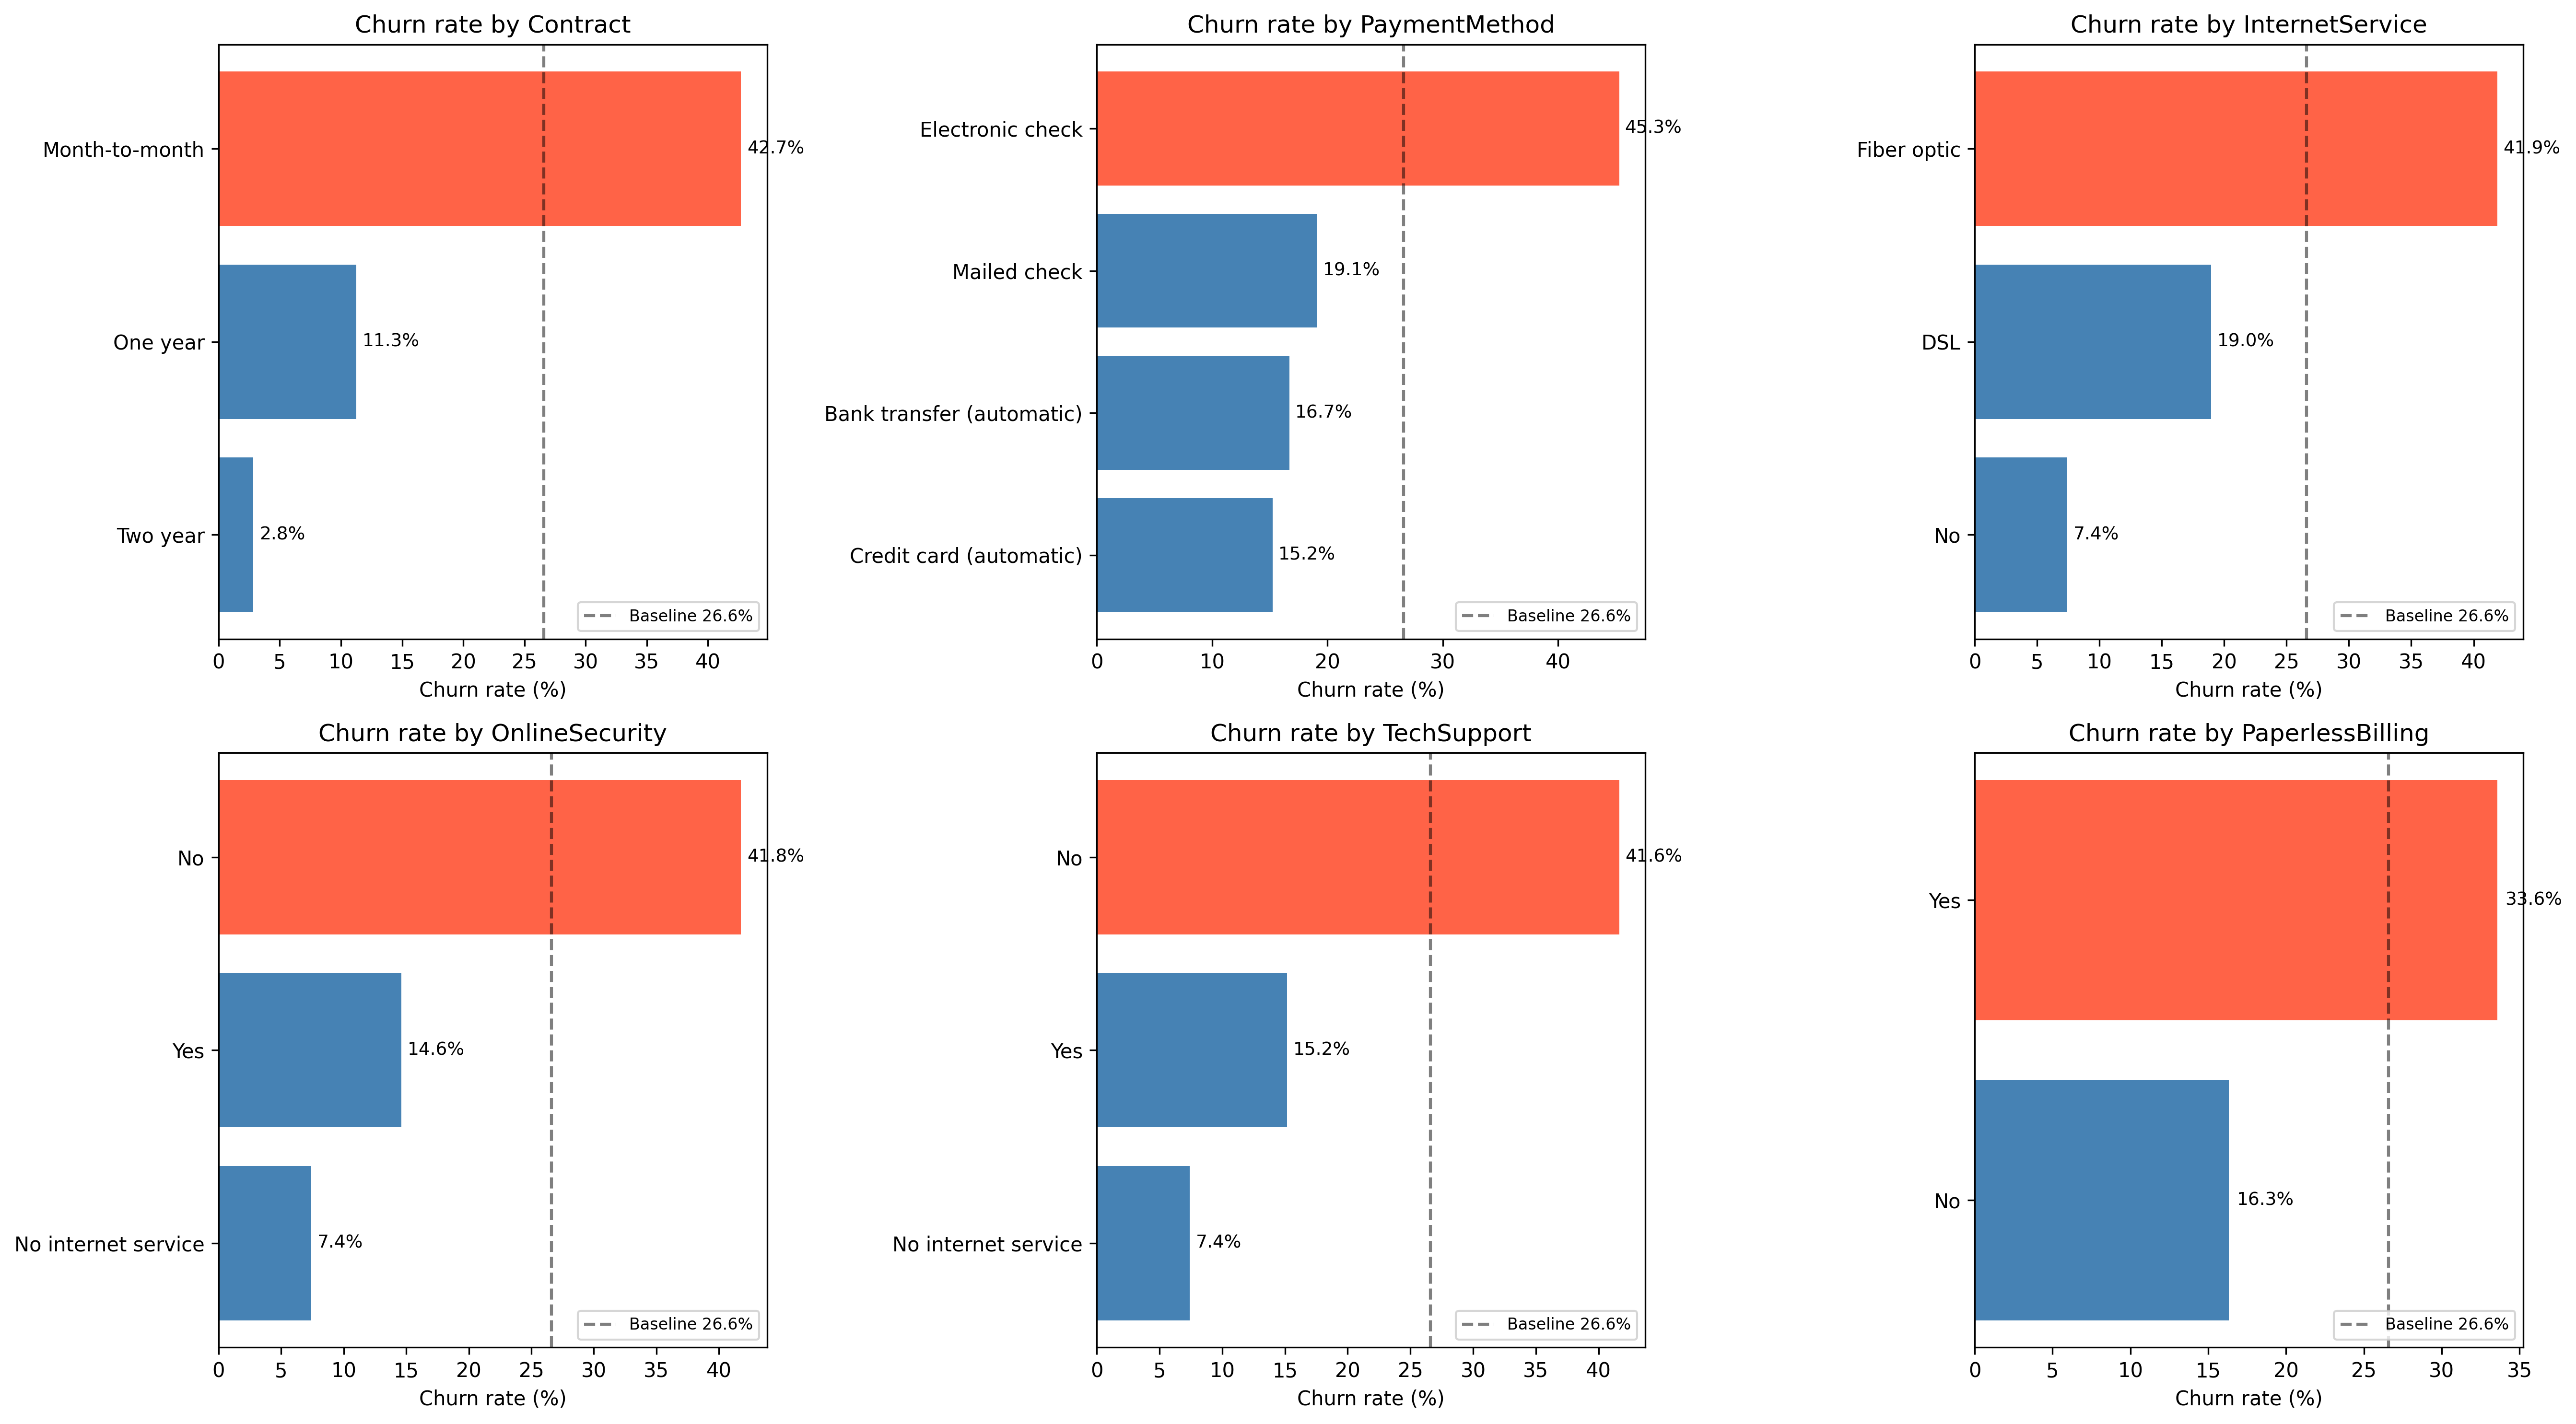

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, features_to_analyze):
    subset = churn_table[churn_table['feature'] == feature].sort_values('churn_rate_pct')
    bars = ax.barh(subset['category'], subset['churn_rate_pct'], 
                   color=['tomato' if x > BASELINE else 'steelblue' for x in subset['churn_rate_pct']])
    ax.axvline(BASELINE, color='black', linestyle='--', alpha=0.5, label=f'Baseline {BASELINE}%')
    ax.set_title(f'Churn rate by {feature}')
    ax.set_xlabel('Churn rate (%)')
    ax.legend(loc='lower right', fontsize=8)
    for bar, val in zip(bars, subset['churn_rate_pct']):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_churn_rate_by_categorical.png", dpi=150, bbox_inches="tight")
plt.show()

Baseline churn rate is **26.6%**. 
Five patterns stand out:

1. **Contract type dominates**. Month-to-month churn **(42.7%)** is ***15× higher*** than 2-year contracts **(2.8%)**. This is partly mechanical — long-contract customers face early-termination fees — but it makes contract length the single highest-leverage policy variable for retention.

2. **Electronic check customers churn at 45.3%**, by far the highest of any payment method. The other three methods (mailed check, bank transfer, credit card) all cluster around 15–19%. The driver is behavioral: customers who actively process each month's bill notice charges they don't like and cancel; auto-pay customers stay by inertia. This is consistent with broader research showing friction reduces churn in subscription businesses.

3. **Fiber optic is a churn paradox**. Premium fiber customers churn at **41.9%,** far above DSL (19.0%) and no-internet (7.4%). Hypothesis: fiber customers pay more, expect more, and are more aware of competitor alternatives. To investigate in in further analysis.

4. **Add-ons create stickiness**. Customers without OnlineSecurity (41.8%) or TechSupport (41.6%) churn at ~3× the rate of customers with them (14.6% and 15.2%). Possibly an engagement signal (invested customers stay) and/or a switching-cost effect (more add-ons make leaving harder).

5. **PaperlessBilling correlates with churn (33.6% vs 16.3%)** but is likely a proxy for tech-savvy, competitor-aware customers rather than a direct driver. Causality runs from "customer type" to both paperless billing and churn behavior — not from billing format to churn.

- Three **high-risk segments** emerge for: month-to-month + electronic check + fiber, and combinations of these traits without protective add-ons.

- TODO — **Feature engineering candidates:**
    - Recode "No internet service" → "No" (6 features)
    - Recode "No phone service" → "No" (MultipleLines)
    - Create `is_auto_pay` binary from PaymentMethod (split manual vs automatic)
    - Create `n_addons` count (sum of how many of the 6 add-ons the customer has) — likely predictive given the stickiness finding
    - Create `is_fiber` binary — the paradox finding suggests fiber deserves its own feature
    - Drop `CustomerID` before modeling

### 3 categorical features that show the strongest visual association with churn

In [36]:
def cramers_v(x, y):
    """Cramér's V — measure of association between two categorical variables."""
    confusion = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(confusion)
    n = confusion.sum().sum()
    r, c = confusion.shape
    denominator = min(r - 1, c - 1)
    if denominator == 0:
        return 0.0
    return np.sqrt((chi2 / n) / denominator)


**Assumption (predictions before running Cramér's V):**

Based on the churn-rate analysis by category features, I expect the top 5 features by Cramér's V (in order) to be:

1. `Contract`       — ~0.40 — because 15× difference between contract types
2. `OnlineSecurity` — ~0.34 — because 3× difference between Yes/No
3. `TechSupport`    — ~0.34 — because 3× difference between Yes/No
4. `InternetService`— ~0.32 — because Fiber paradox; 5× spread
5. `PaymentMethod`  — ~0.30 — because Electronic check is outlier

I expect the following features to have near-zero association (V < 0.05):
- `Gender`          — <0.01 — No reason gender should matter
- `PhoneService`    — ~0.01 — because Almost everyone has it

After running the analysis, I'll compare actuals to these predictions.

In [37]:
categorical_cols = ['Gender', 'SeniorCitizen', 'Partner', 'Dependents',
                    'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

results = []
for col in categorical_cols:
    v = cramers_v(df[col], df['Churn'])
    results.append({'feature': col, 'cramers_v': round(v, 4)})

cramers_table = pd.DataFrame(results).sort_values('cramers_v', ascending=False).reset_index(drop=True)
cramers_table

,feature,cramers_v
0,Contract,0.4101
1,OnlineSecurity,0.3474
2,TechSupport,0.3429
3,InternetService,0.3225
4,PaymentMethod,0.3034
5,OnlineBackup,0.2923
6,DeviceProtection,0.2816
7,StreamingMovies,0.2310
8,StreamingTV,0.2305
9,PaperlessBilling,0.1915


**Interpretation:**

I ranked all 16 categorical features against Churn using Cramér's V, a normalized chi-square statistic that produces a 0–1 score comparable across feature pairs of any cardinality. The top three associations are:

1. **Contract (V = 0.4101)** — the strongest categorical predictor of churn in the dataset.
    - Month-to-month customers churn at 42.7% vs 2.8% for two-year contracts — ~×15 difference between contract types.
    - This is partly mechanical — long-contract customers face early-termination fees whereas short term month-to-month contract customers can leave any time they want.
    - It makes contract length the single highest-leverage policy variable for retention.

2. **OnlineSecurity (V = 0.3474)** — strong association.
    - Customers with OnlineSecurity shows churn at 41.8% vs 14.6% for customers without OnlineSecurity — ~×3 difference.
    - Implies that customers with this 
    - Note that the third category ("No internet service") at 7.4% is structurally tied to InternetService and will be recoded in further analysis.

3. **TechSupport (V = 0.3429)** — nearly tied with OnlineSecurity.
    - TechSupport(41.6% vs 15.2%) having identical pattern to OnlineSecurity (41.8% vs 14.6%) is not a coincidence. 
    - These two features measure highly overlapping customer behavior — flags multicolinearity. Requires further analysis.
    - Implies that customers with OnlineSecurity tends to add-on TechSupport.

**Notable absences from the top:**

- `Gender` (V = 0.0083) and `PhoneService` (V = 0.0114) have essentially zero association with churn — confirming the prior expectation from the dataset reference doc. If a future model ranks gender as important, that's a red flag for label leakage or a bug.

- `MultipleLines` (V = 0.0401) is also showing very weak association because it inherits from PhoneService.

**Methodological note:** Cramér's V quantifies association strength but is *direction-agnostic* — it tells us Contract matters for Churn, but not which contract type drives more churn.The stacked-bar visualizations provide the direction. There is also a known small-sample bias in Cramér's V for which Bergsma's correction exists, but the correction is negligible at n=7,043.

**Comparison to my predictions:**

- My assumptions were correct.

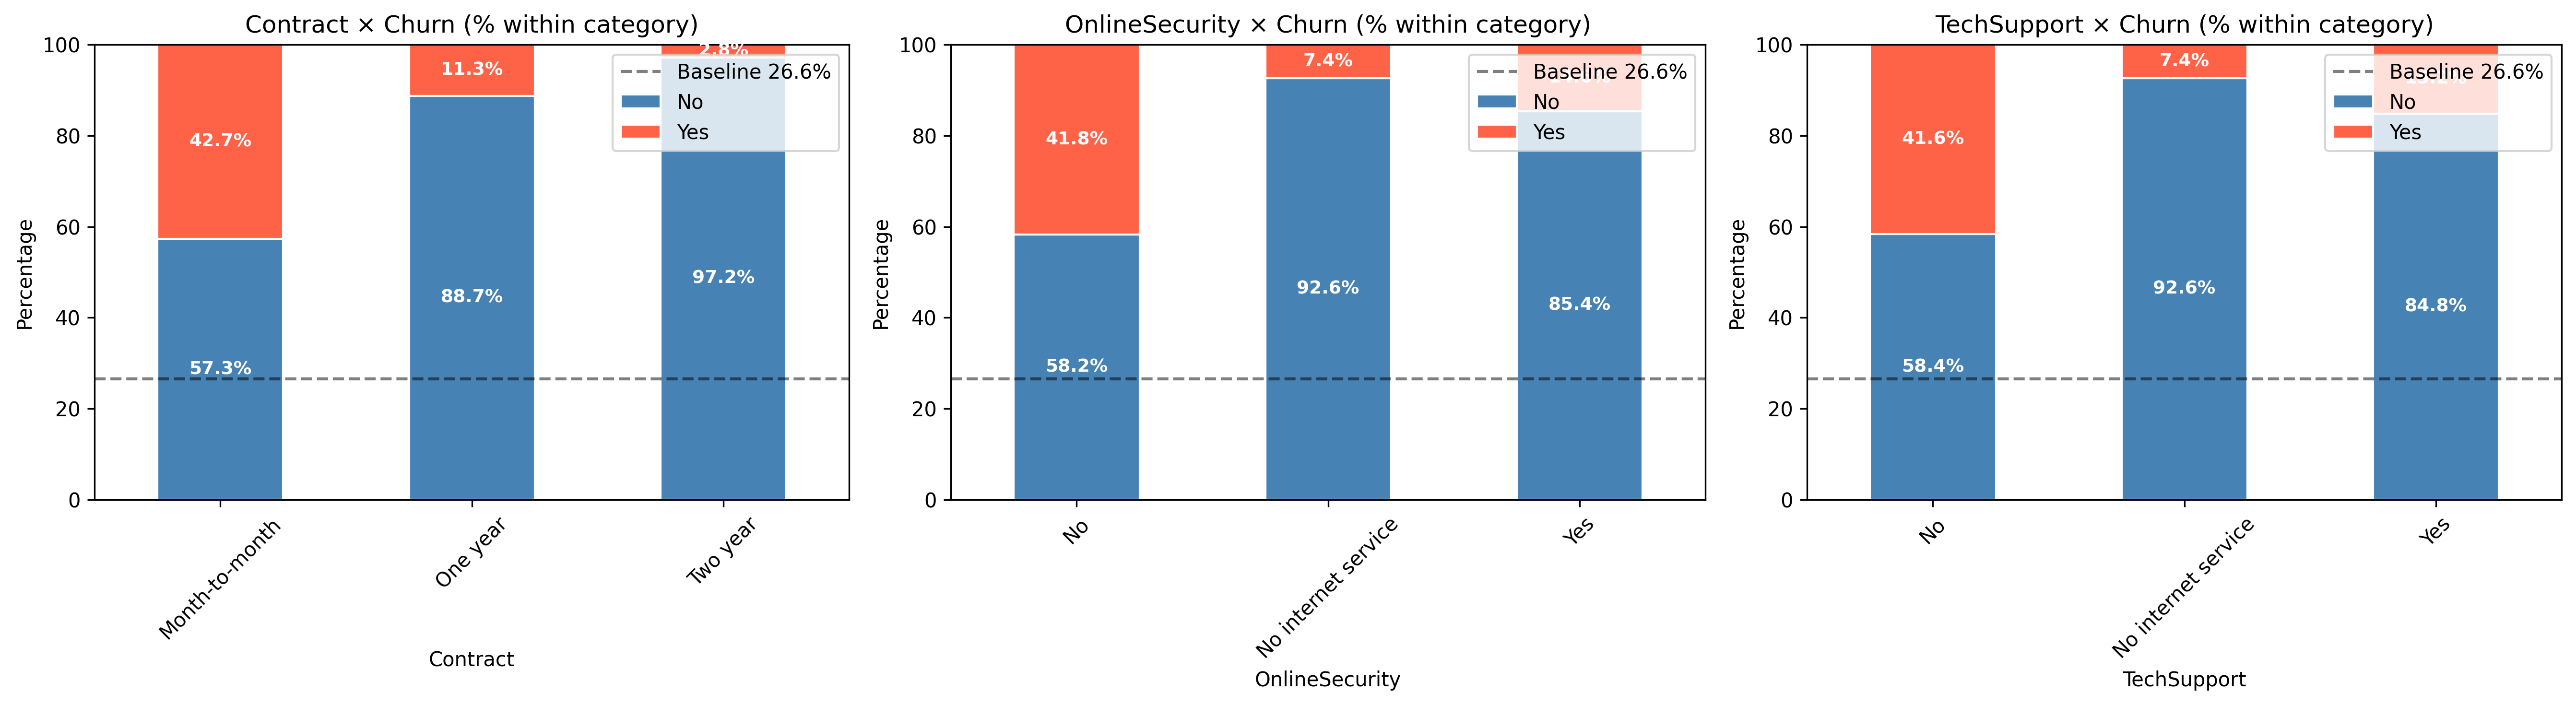

In [38]:
top3 = cramers_table.head(3)['feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, top3):

    ct = pd.crosstab(df[feature], df['Churn'], normalize='index') * 100
    ct = ct[['No', 'Yes']]
    # Plot
    ct.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=['steelblue', 'tomato'],
        edgecolor='white'
    )
    # Add labels inside stacked bars
    for container in ax.containers:
        labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]

        ax.bar_label(
            container,
            labels=labels,
            label_type='center',
            fontsize=9,
            color='white',
            fontweight='bold'
        )
    # Baseline
    ax.axhline(
        26.6,
        color='black',
        linestyle='--',
        alpha=0.5,
        label='Baseline 26.6%'
    )
    ax.set_title(f'{feature} × Churn (% within category)')
    ax.set_ylabel('Percentage')
    ax.set_ylim(0, 100)

    ax.legend(loc='upper right')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "06_top3_stacked_bars.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

- **Stacked-bar visualizations confirm the rankings.** For each of the top 3 features, at least one category has a churn rate substantially above the 26.6% baseline:
    - for `Contract` feature Month-to-month contract churn rate is 42.7% — substantially higher that base line vs 2.8% Two-year churn rate — much lower than base line.
    - for `OnlineSecurity` feature without this service churn rate 41.8% — higher than base line vs 15.6% for those customers with the service — lower than baseline.
    - for `TechSupport` feature without this service churn rate 41.6% — than base line vs 15.2% for those customers with the service — lower than baseline.

- TODO — **Feature engineering candidates:**
    - Recode "No internet service" → "No" (6 features)
    - Recode "No phone service" → "No" (MultipleLines)
    - Create `is_auto_pay` binary from PaymentMethod (split manual vs automatic)
    - Create `n_addons` count (sum of how many of the 6 add-ons the customer has) — likely predictive given the stickiness finding
    - Create `is_fiber` binary — the paradox finding suggests fiber deserves its own feature
    - Drop `CustomerID` before modeling
    - Investigate combining OnlineSecurity + TechSupport into a single has_protective_addons feature if they prove redundant.

- **Implications for modeling (carried forward):**
    - The `OnlineSecurity`/`TechSupport` near-tie (combine? keep separate?)
    - The fact that `Contract` dwarfs every other feature (any modeling implication?)
    - The near-zero features — `Gender`, `PhoneService`, `MultipleLines` (drop? keep?)

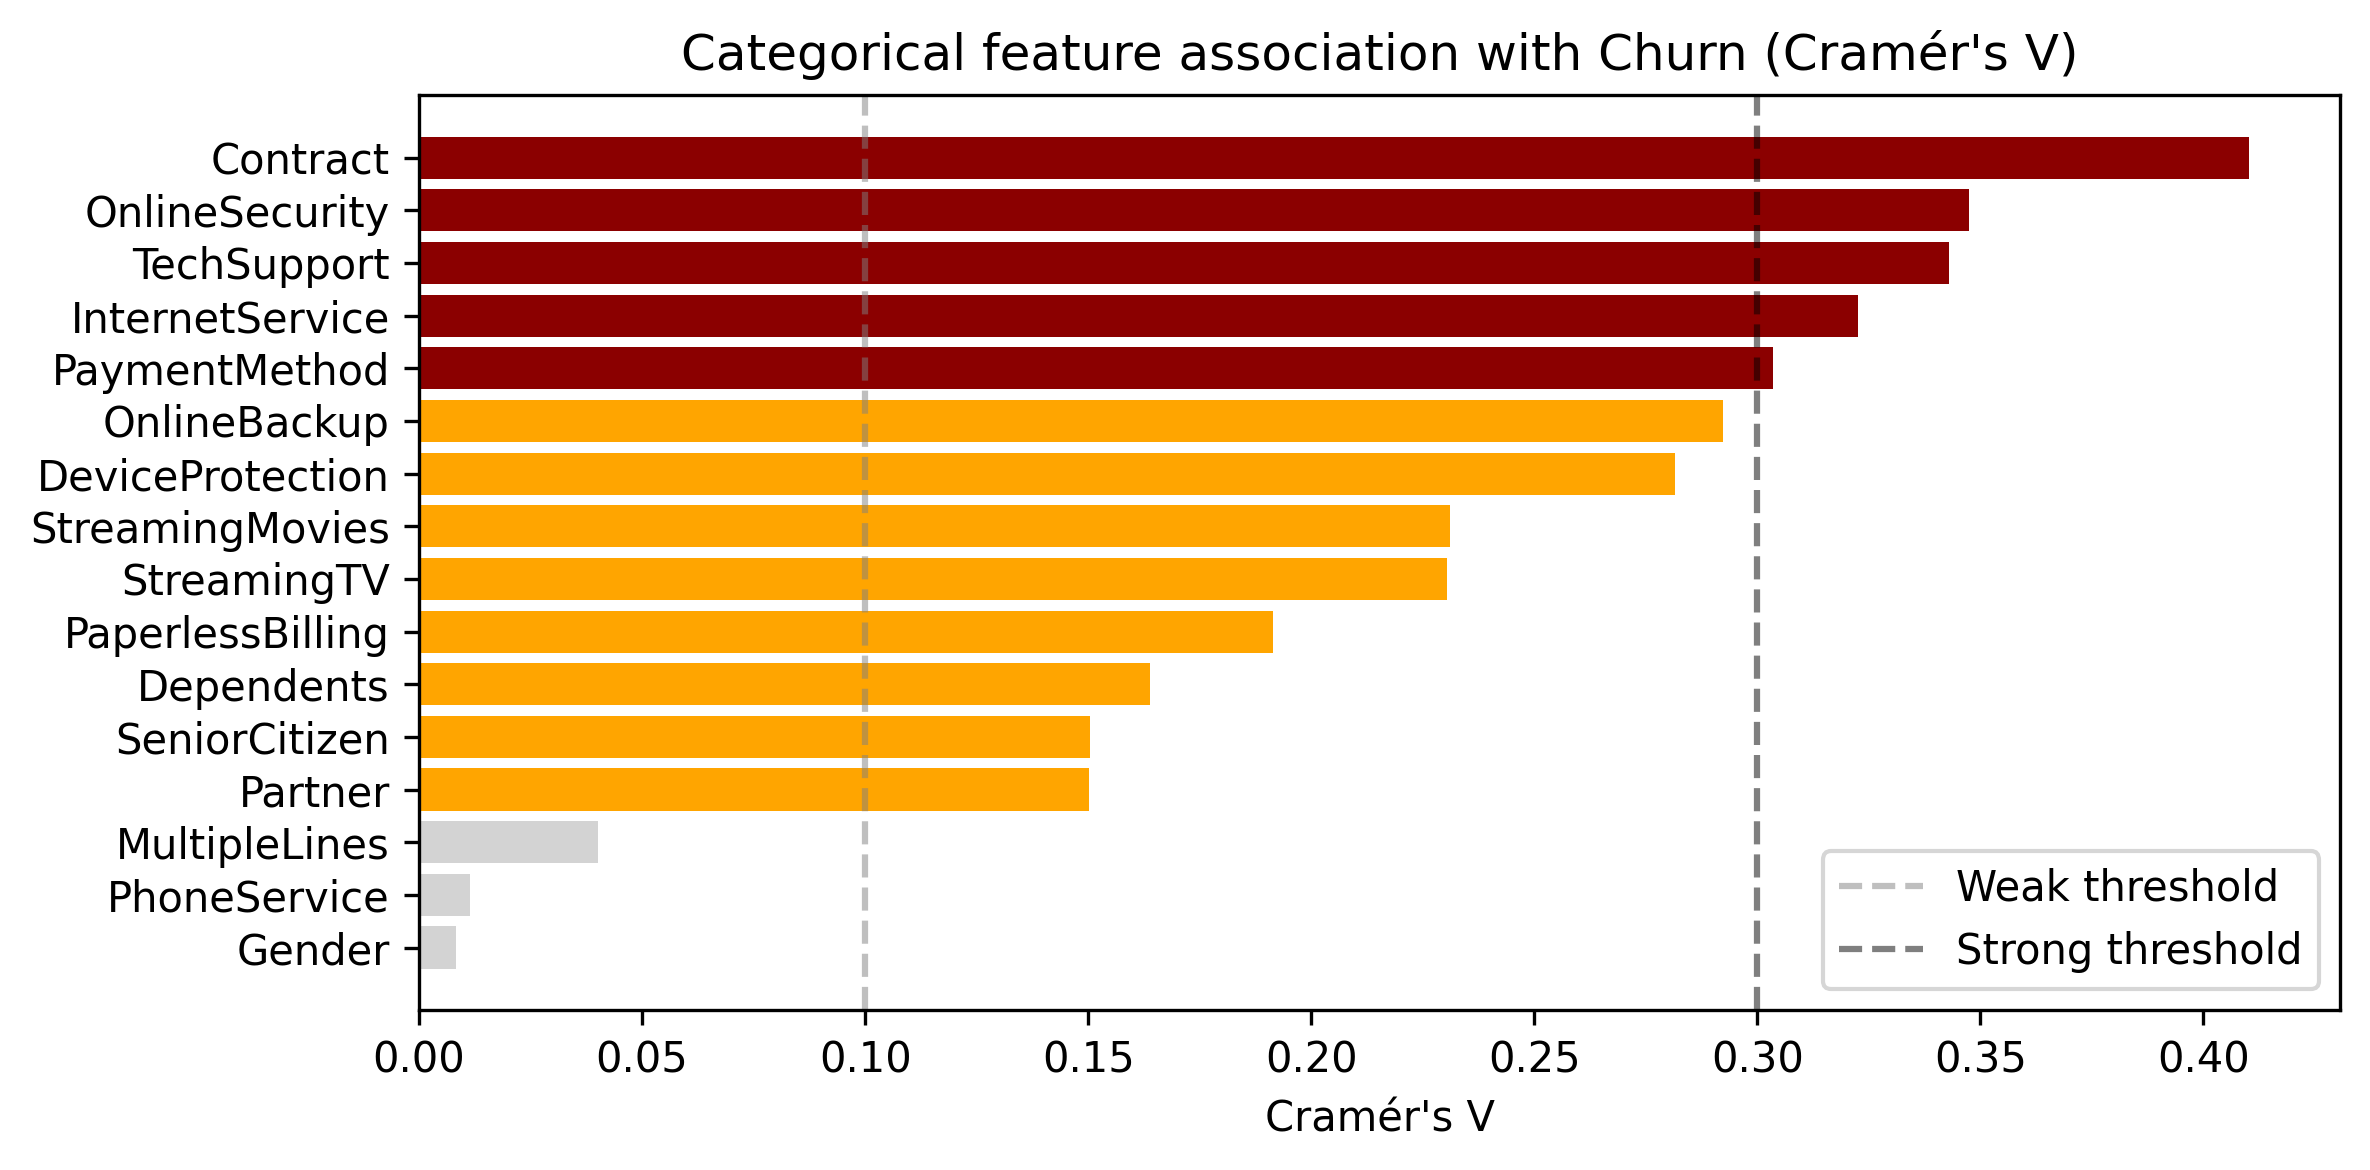

In [39]:
plt.figure(figsize=(8, 4))
colors = ['darkred' if v >= 0.3 else 'orange' if v >= 0.1 else 'lightgray' 
          for v in cramers_table['cramers_v']]
plt.barh(cramers_table['feature'], cramers_table['cramers_v'], color=colors)
plt.gca().invert_yaxis()
plt.axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='Weak threshold')
plt.axvline(0.3, color='black', linestyle='--', alpha=0.5, label='Strong threshold')
plt.xlabel("Cramér's V")
plt.title("Categorical feature association with Churn (Cramér's V)")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_cramers_v_full_ranking.png", dpi=150, bbox_inches='tight')
plt.show()